# Image-to-video dRSA

Loads separate image- and video-session `natraster.mat` files, retains only shared stimulus identities in matching order, aligns the neural responses with sequential model features, and computes image static dRSA and video cross-temporal dRSA.

Set `cfg.use_reliable_channels` to turn the saved image-selectivity reliability filter on or off. The filter is intersected with `good_channels`, and `top_k` is then ranked within the retained pool.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import copy
import json
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import squareform
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path('../..').resolve()
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
    match_feature_stimulus_names,
)
from project_specific_utils import (
    compute_rdm_timeseries, load_natraster, match_timed_static_movie_rasters,
    min_max_normalization,
    normalize_rsa_metric, rowwise_similarity, split_half_filename_suffix,
    window_mean_responses,
)
from useful_stuff.general_utils import (
    TimeSeries, create_RDM, dyn_linear_encoding, get_lagplot, get_lagplot_subset,
    truncate_colormap, spearman,
)
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance


In [101]:
@dataclass
class Cfg:
    monkey_name: str = 'baby1'# "red" #
    vid_exp_name: str = "baby1_260716to24" # 'red_20260720to24' # 
    img_exp_name: str = "baby1_260718to27" # 'red_20260726to27' #

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = None #(84, 186) #None
    top_k: int | None = None # 50
    # Intersect good_channels with the image-session reliability config.
    use_reliable_channels: bool = False #True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    smoothing = 3
    first_frame_latency_window_ms: tuple[float, float] = (0, 500)
    last_frame_latency_window_ms: tuple[float, float] = (2000, 3000)
    latency_scatter_figsize: tuple[float, float] = (8, 5)
    latency_scatter_cmap: str = 'plasma'
    latency_scatter_cmap_min: float = 0.1
    latency_scatter_cmap_max: float = 0.9
    latency_scatter_size: float = 200
    latency_scatter_edge_color: str = 'black'
    latency_scatter_edge_width: float = 0.8
    latency_scatter_n_ticks: int = 6
    latency_scatter_x_padding_fraction: float = 0.08
    latency_scatter_min_x_padding_ms: float = 10
    latency_scatter_y_ticks: tuple[float, ...] = (0, .2, .4, .6, .8, 1)
    latency_scatter_stats_fontsize: int = 12
    centroid_similarity_cutoff: float = 0.02
    peak_similarity_cutoff: float = 0.02
    latency_line_centroid_tick_height: float = 0.05
    latency_line_centroid_tick_width: float = 3
    latency_line_ylim: tuple[float, float] = (-0.05, 0.43)
    image_crop_ms: int = 1000
    image_time_bin_ms: int = 100
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.
    signal_RDM_metric: str = 'cosine_cnt'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700
    video_plot_end_ms: float = 3500
    average_activity_error_alpha: float = 0.2
    tuning_static_window_ms: tuple[float, float] = (100, 500)
    tuning_dynamic_window_ms: tuple[float, float] = (2500, 2900)
    tuning_scatter_figsize: tuple[float, float] = (7, 7)
    tuning_scatter_size: float = 180
    static_dynamic_matrix_figsize: tuple[float, float] = (10, 4)
    static_dynamic_matrix_cmap: str = 'viridis'
    # Leave either limit as None to let Matplotlib infer that bound.
    static_dynamic_matrix_vmin: float | None = 0
    static_dynamic_matrix_vmax: float | None = .65
    dynamic_rdm_slice_times_ms: tuple[int, ...] = (0, 2000, 2500)
    image_2000ms_onset_ms: float = 2000
    image_2250ms_onset_ms: float = 2250
    last_frame_onset_ms: float = 2500
    residual_conditions: tuple[str, ...] = ('2000ms', '2250ms')
    residual_delay_embedding_lags: tuple[int, int] = (-1, 1)
    residual_regression_type: str = 'lr'
    split_half_frame_timing: str = 'last_frame'
    split_half_results_dir: Path | None = None
    split_half_feature_centering: bool = True
    split_half_use_spearman_brown: bool = True
    split_half_spearman_brown_k: float = 2
    split_half_static_reference_window_ms: tuple[float, float] = (0, 1000)
    split_half_figsize: tuple[float, float] = (10, 4)
    split_half_reliability_color: str = 'black'
    split_half_static_dynamic_color: str = 'tab:orange'
    split_half_std_alpha: float = 0.2
    split_half_legend_size: int = 15
    model_name: str = 'ijepa_vith14_1k' #'vjepa2_vitl_fpc64_256'#"dino_v3_h" #
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None
    frame_latency_n_scatterplots: int = 20
    frame_latency_grid_shape: tuple[int, int] = (4, 5)
    frame_latency_window_ms: tuple[float, float] = (-500, 500)
    frame_latency_measure: str = 'centroid'
    frame_latency_grid_figsize: tuple[float, float] = (20, 16)
    frame_latency_scatter_size: float = 55
    example_layer = 30
    rdm_layer: int | str = 28  # Layer index or exact name from layer_names.
    rdm_cmap: str = 'viridis'
    rdm_cmap_min: float = 0.10
    rdm_cmap_max: float = 0.90
    neural_rdm_timepoints_ms: tuple[int, ...] = (
        0, 30, 60, 90, 120, 150, 180, 210, 240, 270,
    )
    neural_rdm_cmap: str = 'YlOrRd'
    neural_rdm_cmap_min: float = 0.0
    neural_rdm_cmap_max: float = 1.0
    linewidth=3
    figs_dir = f"{paths['data_path']}/results/figs_presentation"
    ticks_size = 20
    label_size = 25
    fig_save = True
    frame_500_color  ="#7596C5"
    frame_250_color = "#4A78B5"
    # frame_250_color = "#4673B2"
    # static_color  = "#3969AC"
    static_color = "#3474BD"
    dynamic_color =  "#7F3C8D"# "#A064D6"


cfg = Cfg()
if (
        cfg.static_dynamic_matrix_vmin is not None
        and cfg.static_dynamic_matrix_vmax is not None
        and cfg.static_dynamic_matrix_vmin >= cfg.static_dynamic_matrix_vmax
        ):
    raise ValueError(
        'static_dynamic_matrix_vmin must be smaller than '
        'static_dynamic_matrix_vmax.'
    )
# end if invalid static-to-dynamic matrix limits
if cfg.latency_scatter_n_ticks < 2:
    raise ValueError('latency_scatter_n_ticks must be at least 2.')
# end if cfg.latency_scatter_n_ticks < 2
if cfg.frame_latency_n_scatterplots < 1:
    raise ValueError('frame_latency_n_scatterplots must be positive.')
# end if cfg.frame_latency_n_scatterplots < 1
if np.prod(cfg.frame_latency_grid_shape) != cfg.frame_latency_n_scatterplots:
    raise ValueError(
        'frame_latency_grid_shape must contain exactly '
        'frame_latency_n_scatterplots panels.'
    )
# end if frame-latency grid size is inconsistent
if cfg.frame_latency_window_ms[0] >= cfg.frame_latency_window_ms[1]:
    raise ValueError('frame_latency_window_ms must be increasing.')
# end if frame_latency_window_ms is invalid
if cfg.frame_latency_measure not in {'centroid', 'peak'}:
    raise ValueError(
        "frame_latency_measure must be 'centroid' or 'peak'."
    )
# end if frame_latency_measure is invalid
if not (
        0 <= cfg.latency_scatter_cmap_min
        < cfg.latency_scatter_cmap_max <= 1
        ):
    raise ValueError(
        'The latency scatter colormap limits must satisfy '
        '0 <= min < max <= 1.'
    )
# end if invalid latency scatter colormap limits
if (
        cfg.latency_scatter_x_padding_fraction < 0
        or cfg.latency_scatter_min_x_padding_ms < 0
        ):
    raise ValueError('Latency scatter x-axis padding must be non-negative.')
# end if invalid latency scatter x-axis padding
if cfg.latency_line_centroid_tick_height <= 0:
    raise ValueError('latency_line_centroid_tick_height must be positive.')
# end if cfg.latency_line_centroid_tick_height <= 0
if (
        not np.isfinite(cfg.centroid_similarity_cutoff)
        or cfg.centroid_similarity_cutoff < 0
        ):
    raise ValueError(
        'centroid_similarity_cutoff must be finite and non-negative.'
    )
# end if invalid centroid similarity cutoff
if (
        not np.isfinite(cfg.peak_similarity_cutoff)
        or cfg.peak_similarity_cutoff < 0
        ):
    raise ValueError(
        'peak_similarity_cutoff must be finite and non-negative.'
    )
# end if invalid peak similarity cutoff
if not 0 <= cfg.average_activity_error_alpha <= 1:
    raise ValueError('average_activity_error_alpha must be in [0, 1].')
# end if invalid average-activity error opacity
if cfg.latency_line_centroid_tick_width <= 0:
    raise ValueError('latency_line_centroid_tick_width must be positive.')
# end if cfg.latency_line_centroid_tick_width <= 0
if cfg.latency_line_ylim[0] >= cfg.latency_line_ylim[1]:
    raise ValueError('latency_line_ylim must increase from min to max.')
# end if invalid latency line y-axis limits
if cfg.latency_line_ylim[0] > -cfg.latency_line_centroid_tick_height:
    raise ValueError(
        'latency_line_ylim must include the centroid ticks below zero.'
    )
# end if latency line y-axis excludes centroid ticks
for frame_name, frame_onset_ms, latency_window_ms in (
        ('first', 0, cfg.first_frame_latency_window_ms),
        ('last', cfg.last_frame_onset_ms, cfg.last_frame_latency_window_ms),
        ):
    window_start_ms, window_end_ms = latency_window_ms
    if not window_start_ms <= frame_onset_ms < window_end_ms:
        raise ValueError(
            f'The {frame_name}-frame latency window must contain its onset.'
        )
    # end if frame onset is outside latency window
# end for frame_name, frame_onset_ms, latency_window_ms
cfg
vid_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.vid_exp_name}_natraster_vid.mat'
img_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.img_exp_name}_natraster_img.mat'


In [102]:
# The reusable project loader below aligns all static timing conditions with video.


In [103]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / 'reliable_channels.yaml'
    )
    # The image-session reliability selection is reused for the movie.
    reliable_channels_key = cfg.reliable_channels_key or cfg.img_exp_name
# end if cfg.use_reliable_channels

loaded_vid_rasters, vid_stimulus_names, vid_channel_numbers = load_natraster(
    vid_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_img_rasters, img_stimulus_names, img_channel_numbers = load_natraster(
    img_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(img_channel_numbers, vid_channel_numbers):
    raise ValueError('Image and movie sessions retained different channels.')
# end if channel numbers differ
loaded_channel_numbers = img_channel_numbers

# Average over retained channels and stimuli for the presentation traces.
avg_img_raster = np.mean(loaded_img_rasters, axis=(0, 2))
avg_vid_raster = np.mean(loaded_vid_rasters, axis=(0, 2))


In [104]:
(
    image_rasters,
    video_rasters,
    image_2000ms_rasters,
    image_2250ms_rasters,
    shared_stimuli,
    aligned_names,
) = match_timed_static_movie_rasters(
    loaded_img_rasters, img_stimulus_names,
    loaded_vid_rasters, vid_stimulus_names,
)
image_names = aligned_names['image']
video_names = aligned_names['movie']
print(f'{len(shared_stimuli)} stimuli shared by all four conditions')

# Optionally rank within the range/reliability-filtered channel pool.
if cfg.top_k is not None:
    if cfg.top_k < 1 or cfg.top_k > len(loaded_channel_numbers):
        raise ValueError('top_k must fit inside the retained channel pool.')
    # end if invalid top_k
    channel_scores = video_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = slice(None)
# end if cfg.top_k is not None

selected_channel_numbers = loaded_channel_numbers[channel_indices]
image_rasters = image_rasters[channel_indices, :, :]
image_2000ms_rasters = image_2000ms_rasters[channel_indices, :, :]
image_2250ms_rasters = image_2250ms_rasters[channel_indices, :, :]
video_rasters = video_rasters[channel_indices, :, :]
print(f'Selected MATLAB channels: {selected_channel_numbers.tolist()}')

image_ts = TimeSeries(image_rasters, fs=1000)
image_2000ms_ts = TimeSeries(image_2000ms_rasters, fs=1000)
image_2250ms_ts = TimeSeries(image_2250ms_rasters, fs=1000)
video_ts = TimeSeries(video_rasters, fs=1000)

if cfg.new_fs is not None:
    for neural_ts in (image_ts, image_2000ms_ts, image_2250ms_ts, video_ts):
        neural_ts.resample(cfg.new_fs)
    # end for neural_ts
# end if cfg.new_fs is not None

100 stimuli shared by all four conditions
Selected MATLAB channels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,

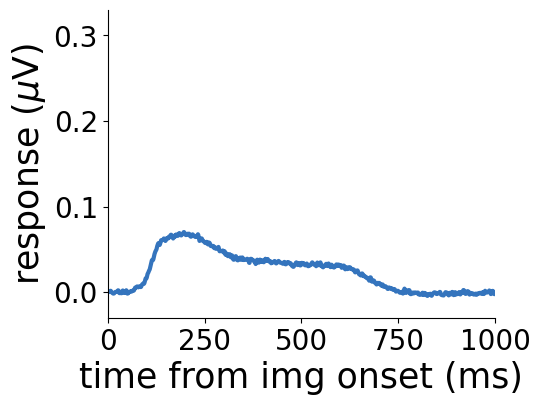

In [105]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, avg_img_raster, linewidth=3, color=cfg.static_color,
)
# for time_bin_edge_ms in time_bin_edges_ms:
#     ax.axvline(
#         time_bin_edge_ms, color="0.6", linestyle="--",
#         linewidth=1, alpha=0.8, zorder=0,
#     )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/{cfg.monkey_name}_example_img_response.pdf",
        bbox_inches="tight",
    )

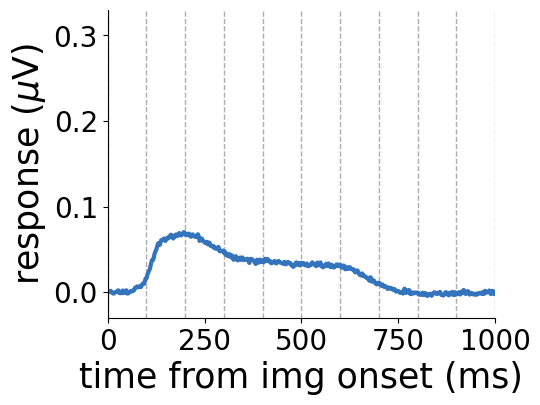

In [106]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, avg_img_raster, linewidth=3, color=cfg.static_color,
)
for time_bin_edge_ms in time_bin_edges_ms:
    ax.axvline(
        time_bin_edge_ms, color="0.6", linestyle="--",
        linewidth=1, alpha=0.8, zorder=0,
    )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/{cfg.monkey_name}_example_img_response_100ms_timebins.pdf",
        bbox_inches="tight",
    )

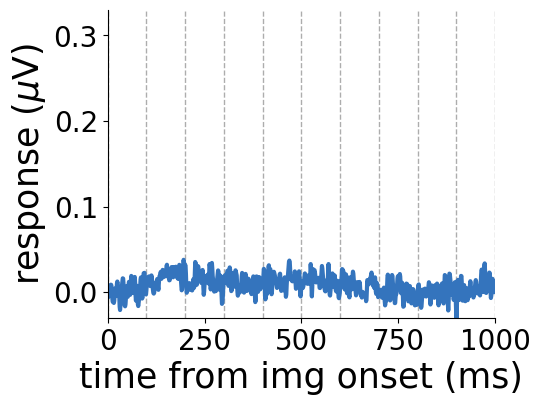

In [107]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, np.mean(loaded_img_rasters[20:25, :, :], axis=(0,2)), linewidth=3, color=cfg.static_color,
)
for time_bin_edge_ms in time_bin_edges_ms:
    ax.axvline(
        time_bin_edge_ms, color="0.6", linestyle="--",
        linewidth=1, alpha=0.8, zorder=0,
    )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/{cfg.monkey_name}_second_example_img_response_100ms_timebins.pdf",
        bbox_inches="tight",
    )

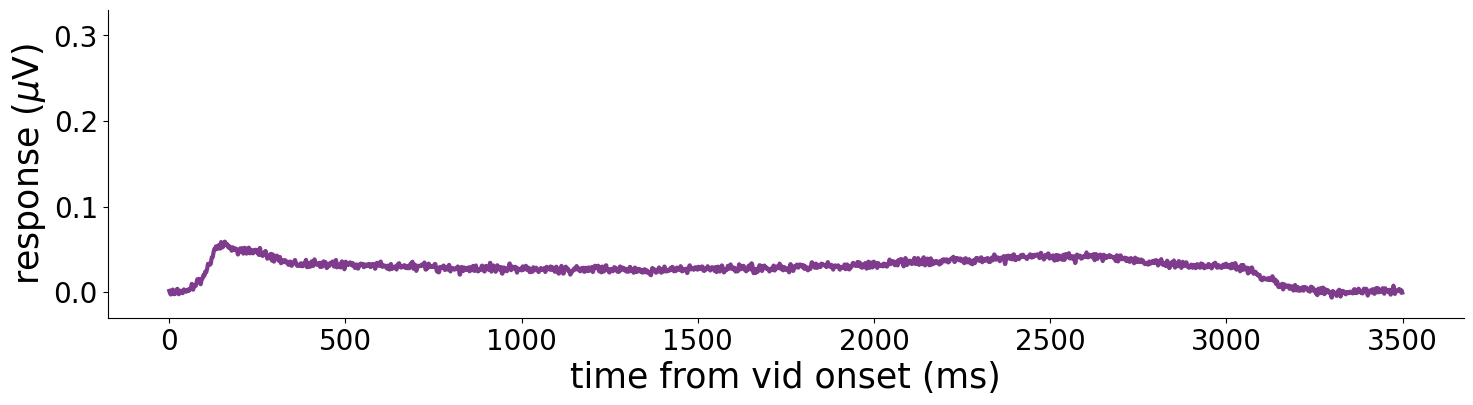

In [108]:
base_width = 5
base_n = 1000

width = base_width * len(avg_vid_raster) / base_n

fig, ax = plt.subplots(figsize=(width, 4))

ax.plot(avg_vid_raster, linewidth=3, color=cfg.dynamic_color)
ax.set_ylim([-0.03, .33])
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("time from vid onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)
if cfg.fig_save:
    fig.savefig(f"{cfg.figs_dir}/{cfg.monkey_name}_example_vid_response.pdf",bbox_inches="tight")

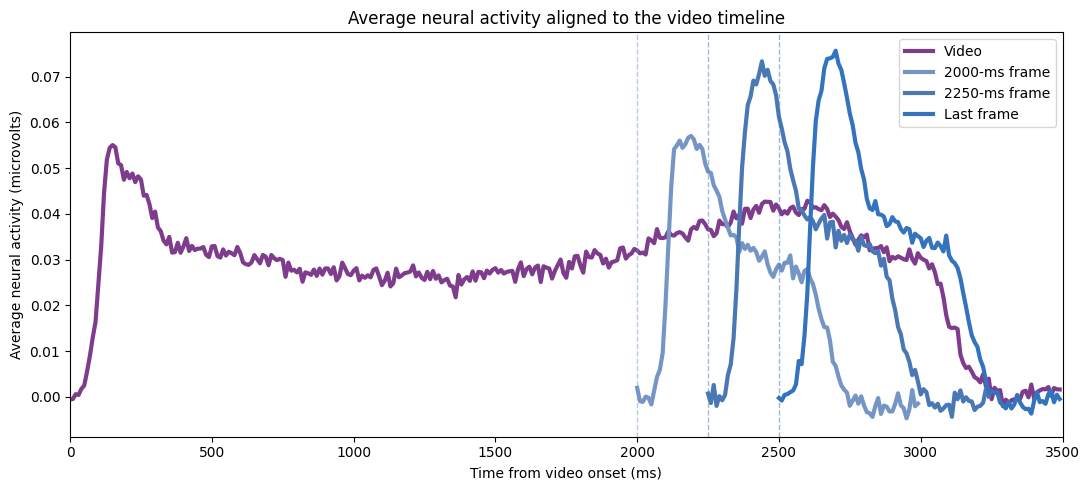

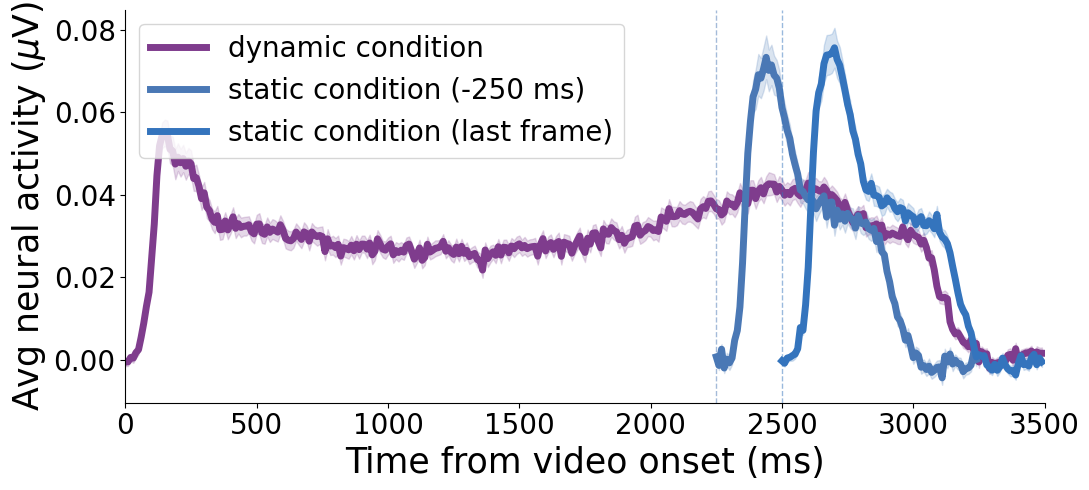

In [109]:
# Average channels first, then estimate uncertainty across matched stimuli.
video_activity_by_stimulus = video_ts.get_array().mean(axis=0)
video_activity = video_activity_by_stimulus.mean(axis=1)
video_activity_sem = (
    video_activity_by_stimulus.std(axis=1, ddof=1)
    / np.sqrt(video_activity_by_stimulus.shape[1])
)
video_time_ms = np.arange(video_activity.size) * 1000 / video_ts.get_fs()
video_plot_mask = video_time_ms < cfg.video_plot_end_ms
# This fallback lets the cell run without recreating the current cfg object.
activity_error_alpha = getattr(
    cfg, 'average_activity_error_alpha', 0.2,
)

static_conditions = (
    (image_2000ms_ts, cfg.image_2000ms_onset_ms, '2000-ms frame', cfg.frame_500_color),
    (image_2250ms_ts, cfg.image_2250ms_onset_ms, '2250-ms frame', cfg.frame_250_color),
    (image_ts, cfg.last_frame_onset_ms, 'Last frame', cfg.static_color),
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    video_time_ms[video_plot_mask], video_activity[video_plot_mask],
    color=cfg.dynamic_color, label='Video', linewidth=cfg.linewidth,
)
for static_ts, onset_ms, label, color in static_conditions:
    static_activity = static_ts.get_array().mean(axis=(0, 2))
    static_time_ms = onset_ms + (
        np.arange(static_activity.size) * 1000 / static_ts.get_fs()
    )
    ax.plot(
        static_time_ms, static_activity, color=color, label=label,
        linewidth=cfg.linewidth,
    )
    ax.axvline(onset_ms, color=color, linestyle='--', linewidth=1, alpha=0.5)
# end for static_ts

ax.set(
    xlim=(0, cfg.video_plot_end_ms),
    xlabel='Time from video onset (ms)',
    ylabel='Average neural activity (microvolts)',
    title='Average neural activity aligned to the video timeline',
)
ax.legend()
fig.tight_layout()

# Overlay the isolated final and preceding frame responses on the movie.
previous_frame_activity_by_stimulus = (
    image_2250ms_ts.get_array().mean(axis=0)
)
previous_frame_activity = previous_frame_activity_by_stimulus.mean(axis=1)
previous_frame_activity_sem = (
    previous_frame_activity_by_stimulus.std(axis=1, ddof=1)
    / np.sqrt(previous_frame_activity_by_stimulus.shape[1])
)
previous_frame_time_ms = (
    cfg.image_2250ms_onset_ms
    + np.arange(previous_frame_activity.size)
    * 1000 / image_2250ms_ts.get_fs()
)
previous_frame_plot_mask = (
    previous_frame_time_ms < cfg.video_plot_end_ms
)

last_frame_activity_by_stimulus = image_ts.get_array().mean(axis=0)
last_frame_activity = last_frame_activity_by_stimulus.mean(axis=1)
last_frame_activity_sem = (
    last_frame_activity_by_stimulus.std(axis=1, ddof=1)
    / np.sqrt(last_frame_activity_by_stimulus.shape[1])
)
last_frame_time_ms = (
    cfg.last_frame_onset_ms
    + np.arange(last_frame_activity.size) * 1000 / image_ts.get_fs()
)
last_frame_plot_mask = last_frame_time_ms < cfg.video_plot_end_ms

last_frame_figure, last_frame_axis = plt.subplots(figsize=(11, 5))
last_frame_axis.fill_between(
    video_time_ms[video_plot_mask],
    (video_activity - video_activity_sem)[video_plot_mask],
    (video_activity + video_activity_sem)[video_plot_mask],
    color=cfg.dynamic_color, alpha=activity_error_alpha,
    label='_nolegend_', zorder=1,
)
last_frame_axis.plot(
    video_time_ms[video_plot_mask], video_activity[video_plot_mask],
    color=cfg.dynamic_color, label='dynamic condition',
    linewidth=cfg.linewidth+2, zorder=2,
)
last_frame_axis.fill_between(
    previous_frame_time_ms[previous_frame_plot_mask],
    (previous_frame_activity - previous_frame_activity_sem)[
        previous_frame_plot_mask
    ],
    (previous_frame_activity + previous_frame_activity_sem)[
        previous_frame_plot_mask
    ],
    color=cfg.frame_250_color, alpha=activity_error_alpha,
    label='_nolegend_', zorder=1,
)
last_frame_axis.plot(
    previous_frame_time_ms[previous_frame_plot_mask],
    previous_frame_activity[previous_frame_plot_mask],
    color=cfg.frame_250_color, label='static condition (-250 ms)',
    linewidth=cfg.linewidth+2, zorder=2,
)
last_frame_axis.fill_between(
    last_frame_time_ms[last_frame_plot_mask],
    (last_frame_activity - last_frame_activity_sem)[
        last_frame_plot_mask
    ],
    (last_frame_activity + last_frame_activity_sem)[
        last_frame_plot_mask
    ],
    color=cfg.static_color, alpha=activity_error_alpha,
    label='_nolegend_', zorder=1,
)
last_frame_axis.plot(
    last_frame_time_ms[last_frame_plot_mask],
    last_frame_activity[last_frame_plot_mask],
    color=cfg.static_color, label='static condition (last frame)',
    linewidth=cfg.linewidth+2, zorder=2,
)
last_frame_axis.axvline(
    cfg.image_2250ms_onset_ms, color=cfg.frame_250_color,
    linestyle='--', linewidth=1, alpha=0.5,
)
last_frame_axis.axvline(
    cfg.last_frame_onset_ms, color=cfg.static_color,
    linestyle='--', linewidth=1, alpha=0.5,
)
last_frame_axis.set(
    xlim=(0, cfg.video_plot_end_ms),
    xlabel='Time from video onset (ms)',
    ylabel=r'Avg neural activity ($\mu$V)',
)
last_frame_axis.legend(fontsize=cfg.ticks_size)
last_frame_axis.tick_params(
    axis='both', labelsize=cfg.ticks_size,
)
last_frame_axis.xaxis.label.set_size(cfg.label_size)
last_frame_axis.yaxis.label.set_size(cfg.label_size)
last_frame_axis.spines['top'].set_visible(False)
last_frame_axis.spines['right'].set_visible(False)
last_frame_figure.tight_layout()

if cfg.fig_save:
    last_frame_figure.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_video_last_two_frames_average_activity_'
        f'{cfg.vid_exp_name}_{cfg.img_exp_name}.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save


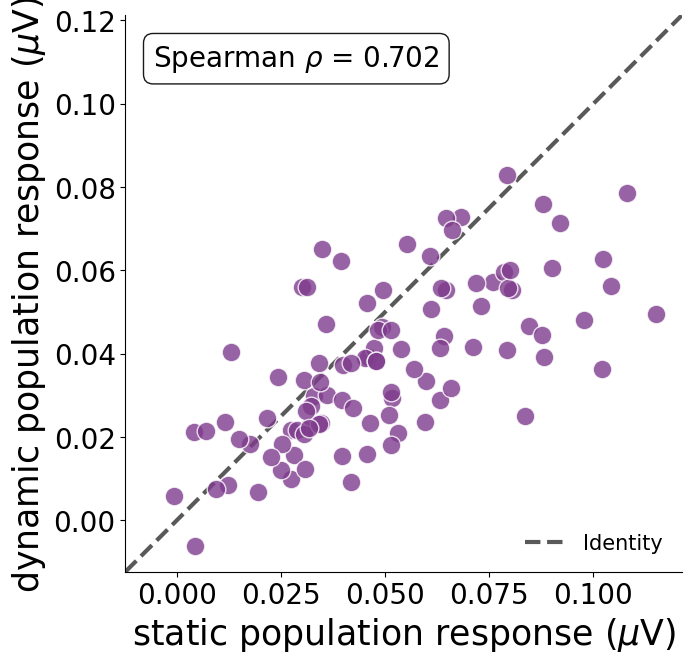

In [110]:
# Average each stimulus response in the same windows as the tuning notebook.
static_channel_responses, _ = window_mean_responses(
    image_ts.get_array(), cfg.tuning_static_window_ms, image_ts.get_fs(),
)
dynamic_channel_responses, _ = window_mean_responses(
    video_ts.get_array(), cfg.tuning_dynamic_window_ms, video_ts.get_fs(),
)

# Mean over channels leaves one absolute response per matched stimulus.
static_population_responses = static_channel_responses.mean(axis=0)
dynamic_population_responses = dynamic_channel_responses.mean(axis=0)
population_rank_correlation = rowwise_similarity(
    static_population_responses[np.newaxis, :],
    dynamic_population_responses[np.newaxis, :],
    metric='spearman',
)[0]

# Give both axes the same limits so the dashed line marks equal responses.
activity_min = min(
    static_population_responses.min(),
    dynamic_population_responses.min(),
)
activity_max = max(
    static_population_responses.max(),
    dynamic_population_responses.max(),
)
activity_padding = 0.05 * max(activity_max - activity_min, 1e-12)
activity_limits = (
    activity_min - activity_padding, activity_max + activity_padding,
)

fig, ax = plt.subplots(figsize=cfg.tuning_scatter_figsize)
ax.scatter(
    static_population_responses, dynamic_population_responses,
    color=cfg.dynamic_color, s=cfg.tuning_scatter_size, alpha=0.8,
    edgecolor='white', linewidth=1, zorder=3,
)
ax.plot(
    activity_limits, activity_limits, '--', color='0.35',
    linewidth=cfg.linewidth, label='Identity', zorder=2,
)
ax.set(
    xlim=activity_limits, ylim=activity_limits, aspect='equal',
    xlabel=r'static population response ($\mu$V)',
    ylabel=r'dynamic population response ($\mu$V)',
)
ax.tick_params(axis='both', labelsize=cfg.ticks_size)
ax.xaxis.label.set_size(cfg.label_size)
ax.yaxis.label.set_size(cfg.label_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, fontsize=cfg.split_half_legend_size)
ax.text(
    0.05, 0.95,
    fr'Spearman $\rho$ = {population_rank_correlation:.3f}',
    transform=ax.transAxes, ha='left', va='top',
    fontsize=cfg.ticks_size,
    bbox=dict(
        boxstyle='round,pad=0.35', facecolor='white',
        edgecolor='black', alpha=0.9,
    ),
    zorder=4,
)
fig.tight_layout()
if cfg.fig_save:
    fig.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_population_static_dynamic_absolute_responses.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save

# DNN-dynamics style RSA

In [111]:
# Load all extracted model layers in numeric order (layer 0, 1, ..., 23).
model_features_dir = cfg.model_features_dir or Path(paths['data_path']) / 'models'
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Reuse the shared subset so image and video model RDMs contain identical stimuli.
image_names_all = [Path(name).name for name in image_names]
video_names_all = [Path(name).name for name in video_names]
# Static image analyses use the final frame from the matching video feature set.
image_model_names = video_names_all

image_neural_ts = TimeSeries(
    image_rasters[:, :cfg.image_crop_ms, :], fs=1000,
)
video_neural_ts = TimeSeries(
    video_rasters, fs=1000,
)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == 'min_max':
    # Re-estimate shared bounds using every condition included in the model analyses.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
# end if cfg.normalization == 'min_max'

print(f'{len(feature_paths)} model layers')
print(f'{len(image_names_all)} image stimuli aligned to final-frame model features')
print(f'{len(video_names_all)} video stimuli aligned to sequential model features')

32 model layers
100 image stimuli aligned to final-frame model features
100 video stimuli aligned to sequential model features


In [112]:
# Compute the neural image RDM once because it is shared by every model layer.
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)

image_drsa.compute_RDM_timeseries(image_ts, 'signal')

image_layer_drsa = []
layer_names = []
model_rdms_by_layer = {}
for feature_path in feature_paths:
    # The final frame has the same visual content as the corresponding static image.
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, image_model_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    model_rdms_by_layer[layer_name] = model_RDM.copy()
    image_drsa.set_RDM(model_RDM, 'model')
    image_layer_drsa.append(image_drsa.compute_static_dRSA().get_array().copy())
    layer_names.append(layer_name)
# end for feature_path

image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f'Image static dRSA: {image_layer_drsa.shape} (layers, neural time)')

Image static dRSA: (32, 100) (layers, neural time)


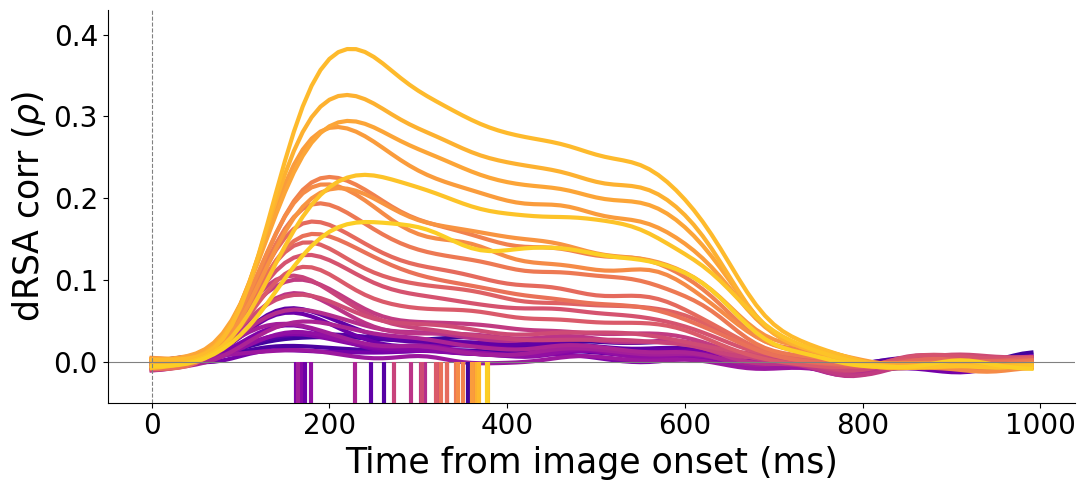

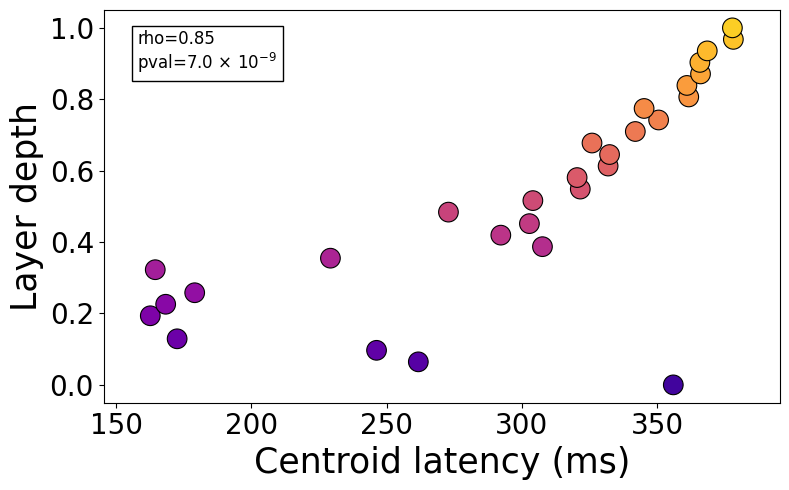

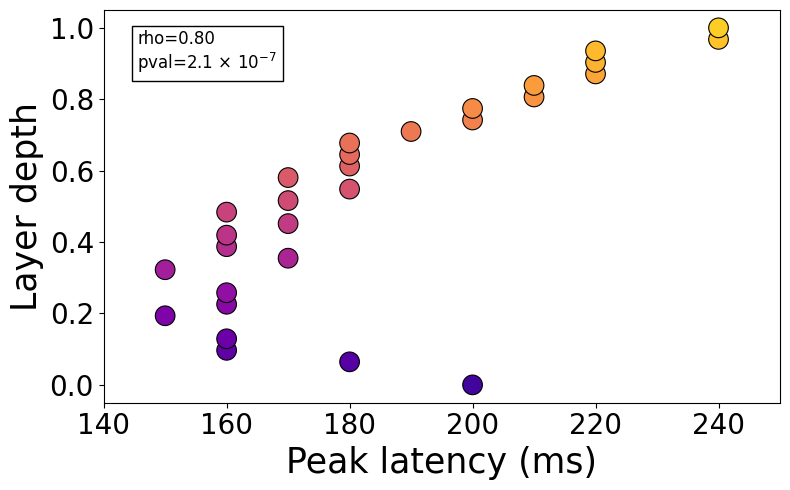

In [113]:
image_time_ms = (
    np.arange(image_layer_drsa.shape[1])
    * 1000 / image_neural_ts.get_fs()
)
image_onset_ms = 0
latency_cmap = truncate_colormap(
    plt.get_cmap(cfg.latency_scatter_cmap),
    cfg.latency_scatter_cmap_min, cfg.latency_scatter_cmap_max,
)
layer_colors = latency_cmap(
    np.linspace(0, 1, len(layer_names)),
)
layer_depths = np.linspace(0, 1, len(layer_names))
image_centroid_latency_ms = []
image_peak_latency_ms = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    # Use only finite correlations above the configured centroid cutoff.
    centroid_similarity = np.where(
        np.isfinite(layer_drsa)
        & (layer_drsa > cfg.centroid_similarity_cutoff),
        layer_drsa, 0,
    )
    # Restrict the peak search to correlations above its own cutoff.
    peak_similarity = np.where(
        np.isfinite(layer_drsa)
        & (layer_drsa > cfg.peak_similarity_cutoff),
        layer_drsa, 0,
    )
    if centroid_similarity.sum() == 0:
        centroid_latency_ms = np.nan
    else:
        centroid_time_ms = np.average(
            image_time_ms, weights=centroid_similarity,
        )
        centroid_latency_ms = centroid_time_ms - image_onset_ms
    # end if centroid_similarity.sum() == 0
    if peak_similarity.sum() == 0:
        peak_latency_ms = np.nan
    else:
        peak_time_ms = image_time_ms[np.argmax(peak_similarity)]
        peak_latency_ms = peak_time_ms - image_onset_ms
    # end if peak_similarity.sum() == 0
    image_centroid_latency_ms.append(centroid_latency_ms)
    image_peak_latency_ms.append(peak_latency_ms)
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth,
    )
    if np.isfinite(centroid_latency_ms):
        ax.vlines(
            centroid_time_ms,
            -cfg.latency_line_centroid_tick_height, 0,
            color=layer_colors[layer_index],
            linewidth=cfg.latency_line_centroid_tick_width, zorder=15,
        )
    # end if np.isfinite(centroid_latency_ms)
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_ylim(cfg.latency_line_ylim)
ax.set_xlabel('Time from image onset (ms)', fontsize=cfg.label_size)
ax.set_ylabel(fr'dRSA corr ($\rho$)', fontsize=cfg.label_size)
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
if cfg.fig_save:
    fig.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_img_dRSA_layer_timecourses_'
        f'{cfg.img_exp_name}.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save

# Plot peak and centroid latencies independently against normalized depth.
image_latency_summaries = (
    ('centroid', np.asarray(image_centroid_latency_ms)),
    ('peak', np.asarray(image_peak_latency_ms)),
)
for latency_name, latency_values_ms in image_latency_summaries:
    valid_layers = np.isfinite(latency_values_ms)
    if not valid_layers.any():
        raise ValueError(f'No finite image {latency_name} latencies.')
    # end if not valid_layers.any()
    finite_latencies_ms = latency_values_ms[valid_layers]
    latency_min_ms = np.min(finite_latencies_ms)
    latency_max_ms = np.max(finite_latencies_ms)
    latency_span_ms = latency_max_ms - latency_min_ms
    x_padding_ms = max(
        cfg.latency_scatter_min_x_padding_ms,
        cfg.latency_scatter_x_padding_fraction * latency_span_ms,
    )
    latency_xlim_ms = (
        latency_min_ms - x_padding_ms,
        latency_max_ms + x_padding_ms,
    )

    figure, axis = plt.subplots(figsize=cfg.latency_scatter_figsize)
    axis.scatter(
        latency_values_ms[valid_layers], layer_depths[valid_layers],
        c=layer_colors[valid_layers], s=cfg.latency_scatter_size,
        edgecolors=cfg.latency_scatter_edge_color,
        linewidths=cfg.latency_scatter_edge_width,
    )
    if valid_layers.sum() >= 2:
        rho_result = spearmanr(
            finite_latencies_ms, layer_depths[valid_layers],
        )
        if np.isfinite(rho_result.pvalue):
            pval_str = f'{rho_result.pvalue:.1e}'
            mantissa, exponent = pval_str.split('e')
            exponent = int(exponent)
            stats_label = (
                f'rho={rho_result.statistic:.2f}\n'
                f'pval={mantissa} × 10$^{{{exponent}}}$'
            )
        else:
            stats_label = f'rho={rho_result.statistic:.2f}\npval=nan'
        # end if np.isfinite(rho_result.pvalue)
    else:
        stats_label = 'rho=nan\npval=nan'
    # end if valid_layers.sum() >= 2
    axis.text(
        0.05, 0.95, stats_label, transform=axis.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='black'),
        fontsize=cfg.latency_scatter_stats_fontsize, zorder=20,
    )
    axis.axvline(0, color='0.6', linewidth=1, linestyle='--')
    axis.set_yticks(cfg.latency_scatter_y_ticks)
    axis.set(
        xlabel=f'{latency_name.capitalize()} latency (ms)',
        ylabel='Layer depth', ylim=(-0.05, 1.05), xlim=latency_xlim_ms,
    )
    axis.locator_params(axis='x', nbins=cfg.latency_scatter_n_ticks)
    axis.tick_params(axis='both', labelsize=cfg.ticks_size)
    axis.xaxis.label.set_size(cfg.label_size)
    axis.yaxis.label.set_size(cfg.label_size)
    axis.spines['top'].set_visible(True)
    axis.spines['right'].set_visible(True)
    figure.tight_layout()

    if cfg.fig_save:
        figure.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_img_dRSA_{latency_name}_'
            f'latency_by_layer_{cfg.img_exp_name}.pdf',
        )
    # end if cfg.fig_save

    plt.show()
# end for latency_name, latency_values_ms


In [114]:
# Select the RDM by its zero-based index or exact layer name.
if isinstance(cfg.rdm_layer, int):
    try:
        selected_rdm_layer = layer_names[cfg.rdm_layer]
    except IndexError as error:
        raise IndexError(
            f'rdm_layer index {cfg.rdm_layer} is outside the available '
            f'{len(layer_names)} layers.'
        ) from error
    # end try
elif isinstance(cfg.rdm_layer, str):
    if cfg.rdm_layer not in model_rdms_by_layer:
        raise KeyError(
            f'Unknown rdm_layer {cfg.rdm_layer!r}. Available layers: '
            f'{layer_names}'
        )
    # end if cfg.rdm_layer not in model_rdms_by_layer
    selected_rdm_layer = cfg.rdm_layer
else:
    raise TypeError('rdm_layer must be an integer index or layer name.')
# end if isinstance(cfg.rdm_layer, int)

if not 0 <= cfg.rdm_cmap_min < cfg.rdm_cmap_max <= 1:
    raise ValueError(
        'rdm_cmap_min and rdm_cmap_max must satisfy '
        '0 <= min < max <= 1.'
    )
# end if invalid colormap range

# Retain only the visually useful portion of the selected base colormap.
base_rdm_cmap = plt.get_cmap("YlGnBu")#cfg.rdm_cmap)
rdm_cmap = truncate_colormap(
    base_rdm_cmap, 0, 1, # cfg.rdm_cmap_min, cfg.rdm_cmap_max,
)
selected_model_rdm = squareform(model_rdms_by_layer[selected_rdm_layer])
model_rdm_vmin = np.nanmin(selected_model_rdm)
model_rdm_vmax = np.nanmax(selected_model_rdm)

fig, ax = plt.subplots(figsize=(6, 6))
image = ax.imshow(
    selected_model_rdm, cmap=rdm_cmap,
    vmin=model_rdm_vmin, vmax=model_rdm_vmax,
)
ax.set(
    xticks=[], yticks=[],
    # title=f'{cfg.model_name}: {selected_rdm_layer} RDM',
)
ax.set_axis_off()
ax.set_position([0, 0, 1, 1])
# fig.colorbar(image, ax=ax, label=f'Distance ({cfg.model_RDM_metric})')
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/{cfg.monkey_name}_img_RDM_model.pdf",
        bbox_inches='tight', pad_inches=0,
    )
plt.close(fig)


In [115]:
# Select exactly ten neural RDM snapshots from the image response.
neural_rdm_timepoints_ms = np.asarray(
    cfg.neural_rdm_timepoints_ms, dtype=float,
)
if neural_rdm_timepoints_ms.shape != (10,):
    raise ValueError('neural_rdm_timepoints_ms must contain exactly 10 times.')
# end if invalid number of timepoints

neural_rdm_ts = image_drsa.get_RDM_timeseries('signal')
neural_rdm_time_indices = np.rint(
    neural_rdm_timepoints_ms * neural_rdm_ts.get_fs() / 1000,
).astype(int)
if (
        np.any(neural_rdm_time_indices < 0)
        or np.any(neural_rdm_time_indices >= len(neural_rdm_ts))
        ):
    raise IndexError(
        'A neural RDM timepoint falls outside the image response: '
        f'{cfg.neural_rdm_timepoints_ms}'
    )
# end if a timepoint is outside the image response

# Convert the selected condensed RDMs to square matrices for plotting.
neural_rdms = np.stack([
    squareform(neural_rdm_ts.get_array()[time_index])
    for time_index in neural_rdm_time_indices
])
neural_rdm_vmin = np.nanmin(neural_rdms)
neural_rdm_vmax = np.nanmax(neural_rdms)

if not 0 <= cfg.neural_rdm_cmap_min < cfg.neural_rdm_cmap_max <= 1:
    raise ValueError(
        'neural_rdm_cmap_min and neural_rdm_cmap_max must satisfy '
        '0 <= min < max <= 1.'
    )
# end if invalid neural RDM colormap range

# Default to the red/orange counterpart of the model RDM's YlGnBu map.
base_neural_rdm_cmap = plt.get_cmap(cfg.neural_rdm_cmap)
neural_rdm_cmap = truncate_colormap(
    base_neural_rdm_cmap,
    .1, cfg.neural_rdm_cmap_max,
)

# Create one model-RDM-sized figure for each neural timepoint.
neural_rdm_figures = []
for time_ms, neural_rdm in zip(neural_rdm_timepoints_ms, neural_rdms):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(
        neural_rdm, cmap=neural_rdm_cmap,
        vmin=neural_rdm_vmin, vmax=neural_rdm_vmax,
    )
    ax.set(xticks=[], yticks=[])
    ax.set_axis_off()
    ax.set_position([0, 0, 1, 1])
    neural_rdm_figures.append(fig)

    if cfg.fig_save:
        fig.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_img_RDM_neural_{time_ms:g}ms.pdf',
            pad_inches=0,
        )
    plt.close(fig)

    # end if cfg.fig_save
# end for time_ms, neural_rdm


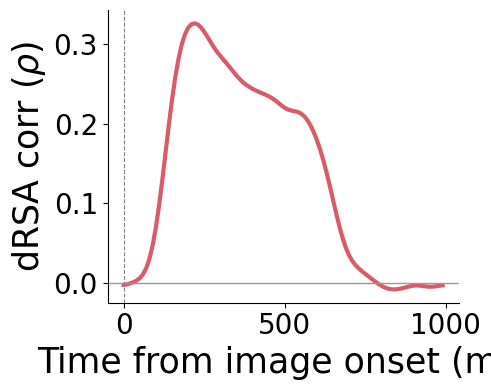

In [116]:
# Plot the selected model layer's similarity to the static neural RDM over time.
selected_static_layer_index = layer_names.index(selected_rdm_layer)
selected_static_similarity = image_layer_drsa[
    selected_static_layer_index,
].copy()
selected_static_layer_color = layer_colors[selected_static_layer_index-10]



if cfg.smoothing:
    selected_static_similarity = gaussian_filter1d(
        selected_static_similarity, sigma=cfg.smoothing,
    )
# end if cfg.smoothing

static_similarity_time_ms = (
    np.arange(selected_static_similarity.size)
    * 1000 / image_drsa.get_RDM_timeseries('signal').get_fs()
)

similarity_base_width = 5
similarity_base_n = 1000
static_similarity_width = (
    similarity_base_width * len(avg_img_raster) / similarity_base_n
)
fig, ax = plt.subplots(figsize=(static_similarity_width, 4))
ax.plot(
    static_similarity_time_ms, selected_static_similarity,
    color=selected_static_layer_color, linewidth=cfg.linewidth,
)
ax.axhline(0, color='0.6', linewidth=1)
# Reuse these limits for every dynamic frame-specific similarity trace.
static_similarity_ylim = ax.get_ylim()
ax.set(
    xlabel='Time from image onset (ms)',
    ylabel=fr'dRSA corr ($\rho$)',
    # title=f'{selected_rdm_layer}: model-neural similarity',
)
ax.tick_params(axis='both', labelsize=cfg.ticks_size)
ax.xaxis.label.set_size(cfg.label_size)
ax.yaxis.label.set_size(cfg.label_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
if cfg.fig_save:
    fig.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_img_static_dRSA_selected_layer.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save

# Video dRSA
Load the previously computed layer-wise model–neural results.


In [117]:
# Select the exact saved result family requested by the active config.
model_neural_results_dir = (
    PROJECT_ROOT / 'results' / 'static_dynamic_neural_model_rsa'
)
model_neural_experiment_name = (
    f'{cfg.vid_exp_name}_vs_{cfg.img_exp_name}'
)
configured_rsa_metric = normalize_rsa_metric(cfg.RSA_metric)
expected_metadata = {
    'experiment_name': model_neural_experiment_name,
    'model_name': cfg.model_name,
    'signal_rdm_metric': cfg.signal_RDM_metric,
    'model_rdm_metric': cfg.model_RDM_metric,
    'rsa_metric_computed': configured_rsa_metric,
    'model_dataset_name': cfg.model_dataset_name,
    'model_pooling': cfg.model_pooling,
    'normalization': cfg.normalization,
    'static_crop_ms': cfg.image_crop_ms,
    'dynamic_crop_ms': None,
    'model_frame_index': -1,
    'new_fs': cfg.new_fs,
}
candidate_result_paths = sorted(
    model_neural_results_dir.glob(
        f'{model_neural_experiment_name}_{cfg.model_name}_*.npz'
    )
)
saved_layer_results = []
for result_path in candidate_result_paths:
    with np.load(result_path, allow_pickle=False) as result_archive:
        result_metadata = json.loads(
            str(result_archive['metadata_json'].item())
        )
        metadata_matches = all(
            result_metadata.get(key) == value
            for key, value in expected_metadata.items()
        )
        if not metadata_matches:
            continue
        # end if saved configuration does not match

        # Compare the saved one-based MATLAB channels with the channels
        # selected above, including reliability and optional top-k filters.
        if 'selected_channel_numbers' in result_archive.files:
            result_channel_numbers = result_archive[
                'selected_channel_numbers'
            ].astype(int)
        elif 'selected_channel_numbers' in result_metadata:
            result_channel_numbers = np.asarray(
                result_metadata['selected_channel_numbers'], dtype=int,
            )
        else:
            # Old all-channel archives did not save the explicit list.
            uses_unfiltered_channels = (
                cfg.good_channels is None
                and not cfg.use_reliable_channels
                and cfg.top_k is None
                and '_all_channels_' in result_path.name
            )
            if not uses_unfiltered_channels:
                continue
            # end if legacy archive cannot prove a channel match
            result_channel_numbers = selected_channel_numbers
        # end if archive contains explicit channel numbers
        if not np.array_equal(
                result_channel_numbers, selected_channel_numbers,
                ):
            continue
        # end if saved channels differ from active channels

        layer_name = str(result_archive['layer_name'].item())
        layer_number_parts = [
            int(name_part) for name_part in layer_name.split('.')
            if name_part.isdigit()
        ]
        if len(layer_number_parts) != 1:
            raise ValueError(
                f'Cannot infer one depth index from layer {layer_name!r}.'
            )
        # end if layer name has no unique numeric depth

        saved_layer_results.append({
            'path': result_path,
            'layer_name': layer_name,
            'layer_number': layer_number_parts[0],
            'dynamic_rsa': result_archive['dynamic_rsa'].copy(),
            'neural_time_ms': (
                result_archive['dynamic_neural_time_ms'].copy()
            ),
            'model_time_ms': (
                result_archive['dynamic_model_time_ms'].copy()
            ),
        })
    # end with np.load
# end for result_path

if len(saved_layer_results) < 2:
    raise FileNotFoundError(
        'No complete saved model–neural family matches the active notebook '
        f'configuration in {model_neural_results_dir}. Found '
        f'{len(saved_layer_results)} matching layers for model={cfg.model_name!r}, '
        f'signal_RDM_metric={cfg.signal_RDM_metric!r}, '
        f'model_RDM_metric={cfg.model_RDM_metric!r}, '
        f'RSA_metric={configured_rsa_metric!r}, and MATLAB channels '
        f'{selected_channel_numbers.tolist()}.'
    )
# end if too few saved layers were found

# Retain true model depth order independently of filename ordering.
saved_layer_results.sort(
    key=lambda result: result['layer_number']
)
saved_layer_names = [result['layer_name'] for result in saved_layer_results]
if len(saved_layer_names) != len(set(saved_layer_names)):
    raise ValueError('The saved model–neural results contain duplicate layers.')
# end if duplicate layer results are present
saved_layer_numbers = [
    result['layer_number'] for result in saved_layer_results
]
expected_layer_numbers = list(range(
    saved_layer_numbers[0], saved_layer_numbers[-1] + 1,
))
if saved_layer_numbers != expected_layer_numbers:
    raise ValueError(
        'The saved model–neural result family is missing intermediate layers.'
    )
# end if the saved layer sequence is incomplete

saved_neural_time_ms = saved_layer_results[0]['neural_time_ms']
saved_model_time_ms = saved_layer_results[0]['model_time_ms']
saved_dynamic_rsa = np.stack([
    result['dynamic_rsa'] for result in saved_layer_results
])
for result in saved_layer_results[1:]:
    if (
            result['dynamic_rsa'].shape != saved_dynamic_rsa.shape[1:]
            or not np.allclose(result['neural_time_ms'], saved_neural_time_ms)
            or not np.allclose(result['model_time_ms'], saved_model_time_ms)
            ):
        raise ValueError(
            'Saved layer results do not share the same RSA shape and time grids.'
        )
    # end if saved layer axes are inconsistent
# end for result

# Expose the loaded matrices under the names used by the presentation plots.
video_layer_names = saved_layer_names.copy()
video_layer_drsa = {
    layer_name: saved_dynamic_rsa[layer_index]
    for layer_index, layer_name in enumerate(video_layer_names)
}
video_layer_depths = np.linspace(0, 1, len(video_layer_names))
video_layer_cmap = truncate_colormap(
    plt.get_cmap(cfg.latency_scatter_cmap),
    cfg.latency_scatter_cmap_min, cfg.latency_scatter_cmap_max,
)
video_layer_colors = video_layer_cmap(video_layer_depths)

# Resolve the configured presentation layer in the saved model's depth order.
if isinstance(cfg.rdm_layer, int):
    try:
        selected_video_rdm_layer = video_layer_names[cfg.rdm_layer]
    except IndexError as error:
        raise IndexError(
            f'rdm_layer={cfg.rdm_layer} is outside the '
            f'{len(video_layer_names)} saved video layers.'
        ) from error
    # end try
elif cfg.rdm_layer in video_layer_names:
    selected_video_rdm_layer = cfg.rdm_layer
else:
    raise KeyError(
        f'Video layer {cfg.rdm_layer!r} is absent from the saved results.'
    )
# end if isinstance(cfg.rdm_layer, int)
selected_video_layer_index = video_layer_names.index(
    selected_video_rdm_layer
)
selected_video_layer_color = video_layer_colors[
    selected_video_layer_index
]

if not 0 <= cfg.example_layer < len(video_layer_names):
    raise IndexError(
        f'example_layer={cfg.example_layer} is outside the saved video layers.'
    )
# end if cfg.example_layer is outside the saved video layers

# Read the saved axes directly; no neural–model correlations are recomputed.
selected_saved_result = next(
    result for result in saved_layer_results
    if result['layer_name'] == selected_video_rdm_layer
)
with np.load(selected_saved_result['path'], allow_pickle=False) as result_archive:
    selected_result_metadata = json.loads(
        str(result_archive['metadata_json'].item())
    )
    saved_dynamic_stimulus_names = (
        result_archive['dynamic_stimulus_names'].astype(str).tolist()
    )
    source_model_fs = float(result_archive['source_model_fs'].item())
    model_fs = float(result_archive['model_fs'].item())
# end with np.load

# Reconstruct only the selected layer's frame RDMs used by the next display cell.
# This does not recompute any model-versus-neural dRSA matrix.
selected_feature_stimulus_names = match_feature_stimulus_names(
    selected_result_metadata['feature_path'],
    saved_dynamic_stimulus_names,
)
selected_model_features, loaded_video_layer, layer_model_fs = (
    load_aligned_video_features(
        selected_result_metadata['feature_path'],
        selected_feature_stimulus_names,
        frame_index=None,
    )
)
if loaded_video_layer != selected_video_rdm_layer:
    raise ValueError('The selected feature file contains an unexpected layer.')
# end if loaded layer name does not match
if not np.isclose(layer_model_fs, source_model_fs):
    raise ValueError('Saved and loaded source model frequencies differ.')
# end if source model frequencies differ
selected_model_ts = TimeSeries(selected_model_features, fs=layer_model_fs)
selected_model_ts.resample(model_fs)
selected_dynamic_model_rdms = compute_rdm_timeseries(
    selected_model_ts.get_array(),
    cfg.model_RDM_metric,
)
if selected_dynamic_model_rdms.shape[0] != saved_model_time_ms.size:
    raise ValueError(
        'Selected model RDM timecourse does not match the saved model-time axis.'
    )
# end if selected model RDM timecourse has the wrong length

example_video_drsa = video_layer_drsa[
    video_layer_names[cfg.example_layer]
]
neural_time_ms = saved_neural_time_ms.copy()
model_time_ms = saved_model_time_ms.copy()
print(
    f'Loaded {len(video_layer_names)} saved video dRSA layers: '
    f'{example_video_drsa.shape} (neural time, model time); '
    f'model features were sampled at {source_model_fs:g} Hz and saved at '
    f'{model_fs:g} Hz.'
)
# EOF


FileNotFoundError: No complete saved model–neural family matches the active notebook configuration in /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_neural_model_rsa. Found 0 matching layers for model='ijepa_vith14_1k', signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', RSA_metric='spearman', and MATLAB channels [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 1

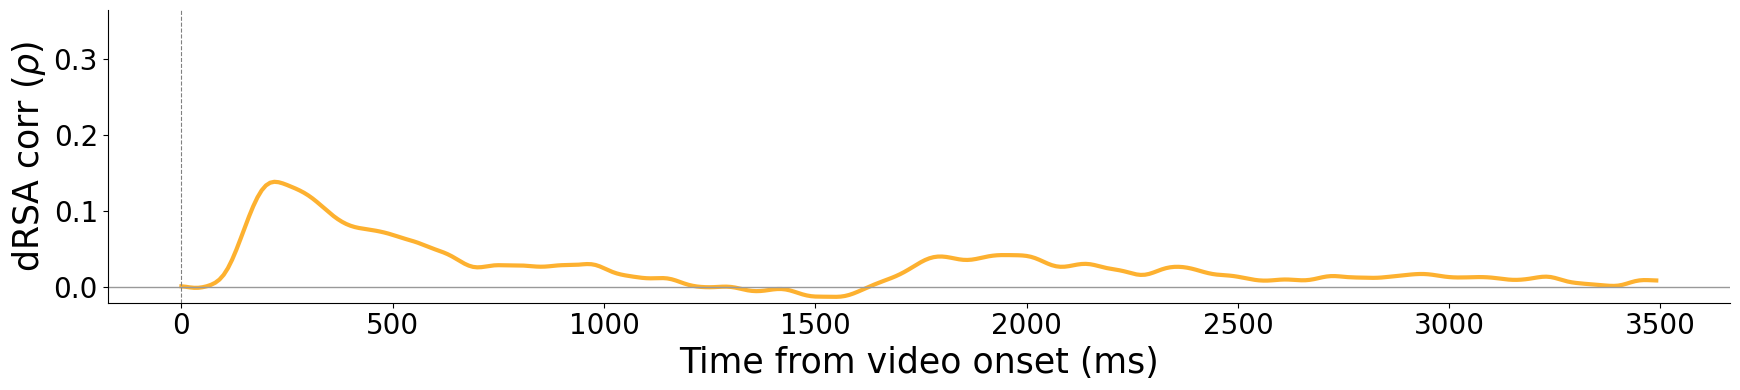

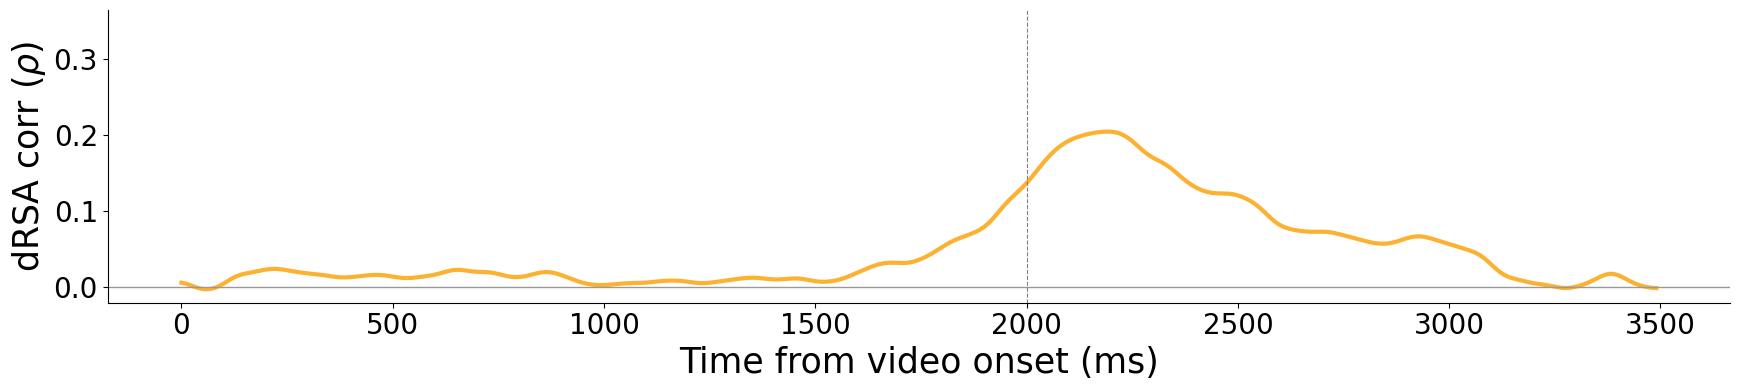

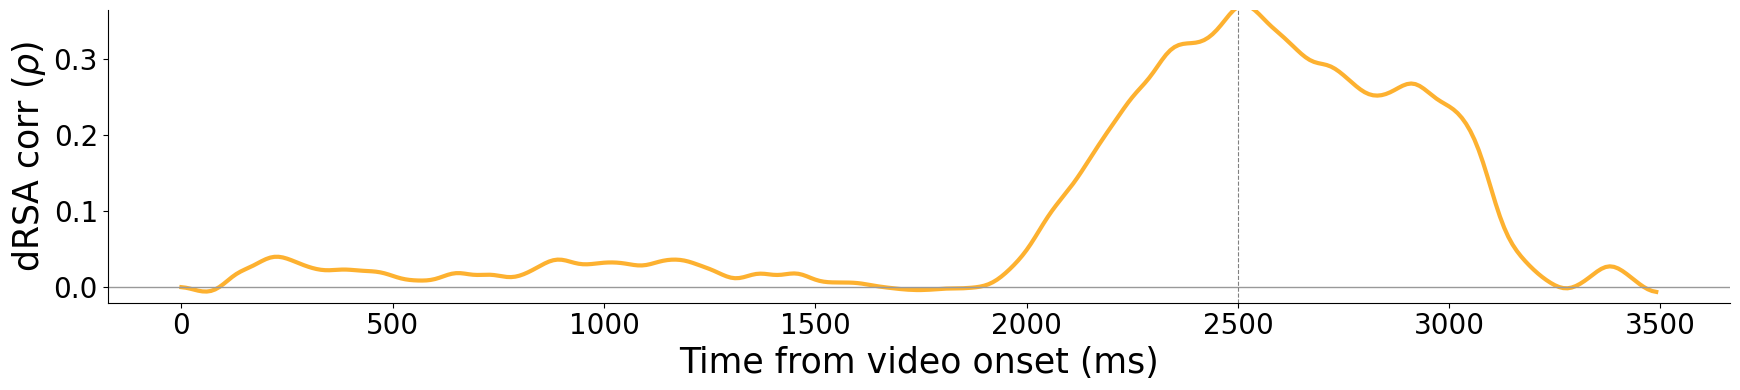

Dynamic frame RDMs: (3, 100, 100)


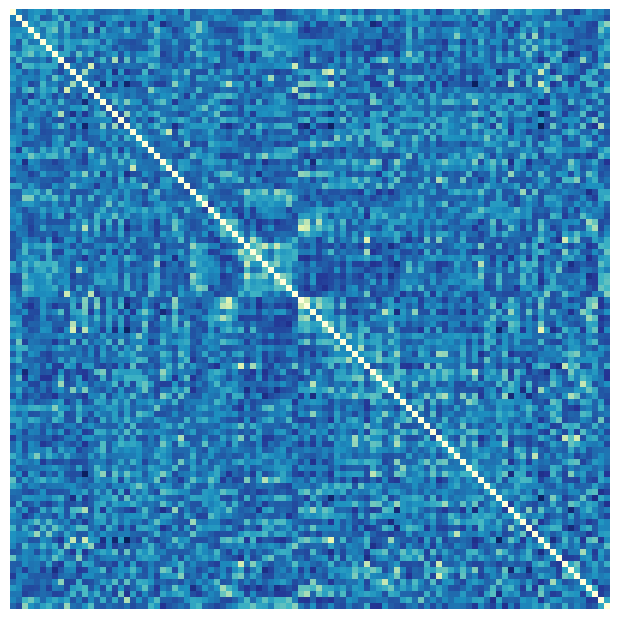

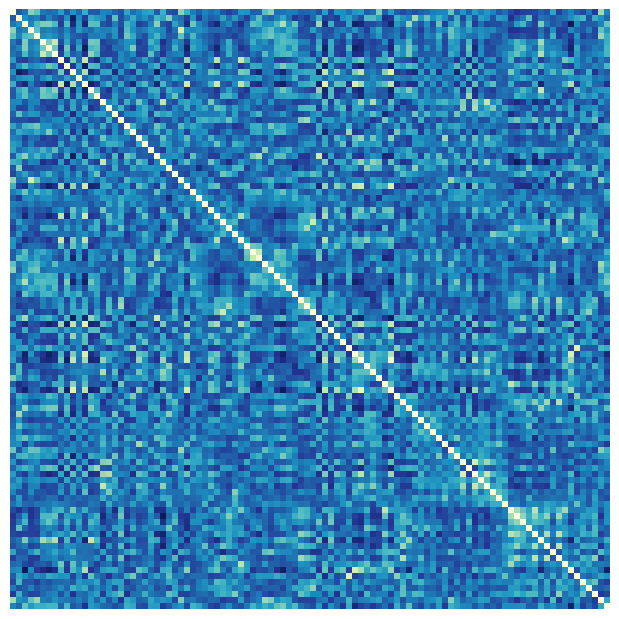

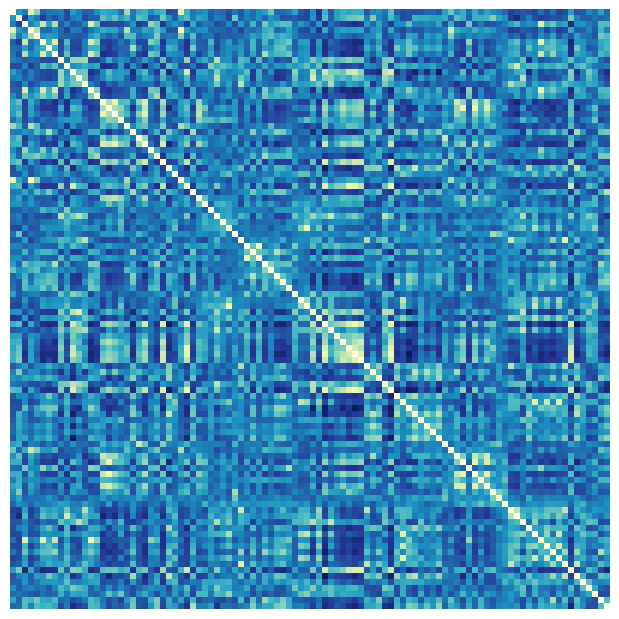

In [ ]:
# Plot configurable model-time slices of the selected layer's dynamic dRSA matrix.
dynamic_rdm_slice_times_ms = np.asarray(
    cfg.dynamic_rdm_slice_times_ms, dtype=float,
)
if dynamic_rdm_slice_times_ms.shape != (3,):
    raise ValueError('dynamic_rdm_slice_times_ms must contain exactly 3 times.')
# end if invalid number of dynamic slices

selected_dynamic_drsa = video_layer_drsa[selected_video_rdm_layer]
expected_pair_count = (
    len(saved_dynamic_stimulus_names)
    * (len(saved_dynamic_stimulus_names) - 1) // 2
)
expected_dynamic_rdm_shape = (
    selected_dynamic_drsa.shape[1], expected_pair_count,
)
if selected_dynamic_model_rdms.shape != expected_dynamic_rdm_shape:
    raise ValueError(
        'Unexpected dynamic model RDM shape: '
        f'{selected_dynamic_model_rdms.shape} != '
        f'{expected_dynamic_rdm_shape}.'
    )
# end if selected_dynamic_model_rdms.shape
dynamic_rdm_slice_indices = np.asarray([
    np.argmin(np.abs(saved_model_time_ms - slice_time_ms))
    for slice_time_ms in dynamic_rdm_slice_times_ms
])
if np.any(
        np.abs(
            saved_model_time_ms[dynamic_rdm_slice_indices]
            - dynamic_rdm_slice_times_ms
        ) > 0.5 * 1000 / model_fs
        ):
    raise IndexError(
        'A dynamic RDM slice falls outside the model time axis: '
        f'{cfg.dynamic_rdm_slice_times_ms}'
    )
# end if a dynamic slice is outside the model time axis

selected_dynamic_slices = selected_dynamic_drsa[
    :, dynamic_rdm_slice_indices,
].T.copy()
if cfg.smoothing:
    selected_dynamic_slices = gaussian_filter1d(
        selected_dynamic_slices, sigma=cfg.smoothing, axis=1,
    )
# end if cfg.smoothing

dynamic_similarity_time_ms = (
    saved_neural_time_ms.copy()
)
similarity_base_width = 5
similarity_base_n = 1000
dynamic_similarity_width = (
    similarity_base_width * len(avg_vid_raster) / similarity_base_n
)

for slice_time_ms, dynamic_slice in zip(
        dynamic_rdm_slice_times_ms, selected_dynamic_slices,
        ):
    # Give every slice the same canvas dimensions as the dynamic response.
    fig, ax = plt.subplots(figsize=(dynamic_similarity_width, 4))
    ax.plot(
        dynamic_similarity_time_ms, dynamic_slice,
        color=selected_video_layer_color, linewidth=cfg.linewidth,
    )
    ax.axhline(0, color='0.6', linewidth=1)
    ax.set_ylim(static_similarity_ylim)

    # Mark the onset of the model frame represented by this matrix slice.
    ax.axvline(
        slice_time_ms, color='grey', linewidth=0.8, linestyle='--',
    )
    ax.set(
        xlabel='Time from video onset (ms)',
        ylabel=fr'dRSA corr ($\rho$)',
        # title=f'{selected_rdm_layer}: frame at {slice_time_ms:g} ms',
    )
    ax.tick_params(axis='both', labelsize=cfg.ticks_size)
    ax.xaxis.label.set_size(cfg.label_size)
    ax.yaxis.label.set_size(cfg.label_size)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()

    if cfg.fig_save:
        fig.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_vid_dynamic_dRSA_'
            f'{selected_video_rdm_layer}_{slice_time_ms:g}ms.pdf',
            bbox_inches='tight',
        )
    # end if cfg.fig_save

    plt.show()
# end for slice_time_ms, dynamic_slice

# Show the selected frame RDMs with the static image RDM's exact scale and map.
selected_dynamic_rdms = np.stack([
    squareform(selected_dynamic_model_rdms[time_index])
    for time_index in dynamic_rdm_slice_indices
])
print(f'Dynamic frame RDMs: {selected_dynamic_rdms.shape}')
for slice_time_ms, dynamic_rdm in zip(
        dynamic_rdm_slice_times_ms, selected_dynamic_rdms,
        ):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(
        dynamic_rdm, cmap=rdm_cmap,
    )
    ax.set(xticks=[], yticks=[])
    ax.set_axis_off()
    ax.set_position([0, 0, 1, 1])

    if cfg.fig_save:
        fig.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_vid_RDM_model_'
            f'{selected_video_rdm_layer}_{slice_time_ms:g}ms.pdf',
            bbox_inches='tight', pad_inches=0,
        )
    # end if cfg.fig_save

    plt.show()
# end for slice_time_ms, dynamic_rdm

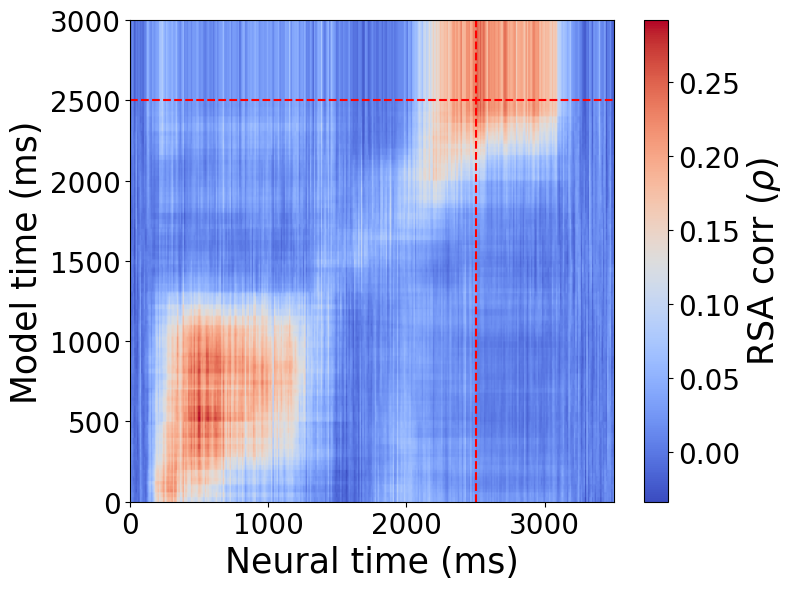

In [ ]:
# Express both matrix axes in milliseconds rather than sample indices.
last_frame_ms = cfg.last_frame_onset_ms
neural_time_end_ms = saved_neural_time_ms[-1] + 1000 / model_fs
model_time_end_ms = saved_model_time_ms[-1] + 1000 / model_fs

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    example_video_drsa.T, aspect='auto', origin='lower', cmap='coolwarm',
    extent=(0,neural_time_end_ms, 0, model_time_end_ms),
)
ax.axvline(last_frame_ms, linestyle='--', color='red')
ax.axhline(last_frame_ms, linestyle='--', color='red')
ax.set(
    xlabel='Neural time (ms)',
    ylabel='Model time (ms)',
)
ax.tick_params(axis='both', labelsize=cfg.ticks_size)
ax.xaxis.label.set_size(cfg.label_size)
ax.yaxis.label.set_size(cfg.label_size)
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label(
    fr'RSA corr ($\rho$)', fontsize=cfg.label_size,
)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
fig.tight_layout()

if cfg.fig_save:
    fig.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_vid_dRSA_matrix_'
        f'{cfg.model_name}_'
        f'{video_layer_names[cfg.example_layer]}.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save

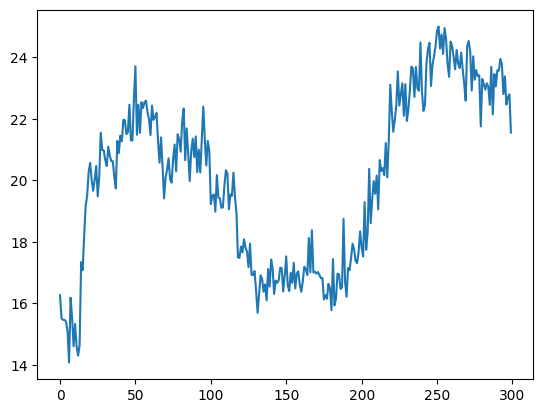

In [ ]:
from useful_stuff.general_utils import softmax
diagonals = []
n_layers = np.arange(len(video_layer_drsa.keys()))
T = 0.1
for idx, l in enumerate(video_layer_names):
    d = np.diag(video_layer_drsa[l], k=0)
    diagonals.append(d)
diagonals = np.array(diagonals)
softmax_lp = []
for t in range(diagonals.shape[1]):
    tpt = softmax(diagonals[:,t], T=T)
    tpt = tpt@n_layers
    softmax_lp.append(tpt)
plt.plot(softmax_lp);

In [ ]:
image_layer_drsa.shape

(32, 100)

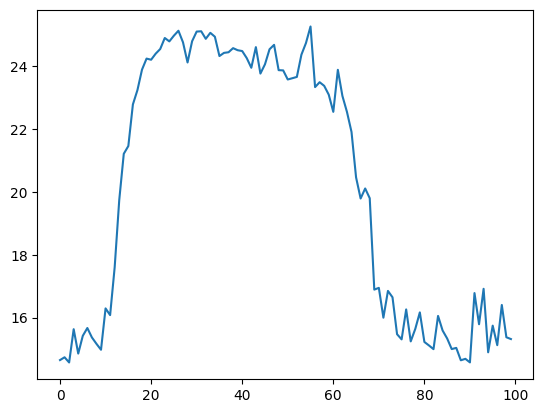

In [ ]:
from useful_stuff.general_utils import softmax
diagonals = []
n_layers = np.arange(len(video_layer_drsa.keys()))
T = 0.1
softmax_lp = []
for t in range(image_layer_drsa.shape[1]):
    tpt = softmax(image_layer_drsa[:,t], T=T)
    tpt = tpt@n_layers
    softmax_lp.append(tpt)
plt.plot(softmax_lp);

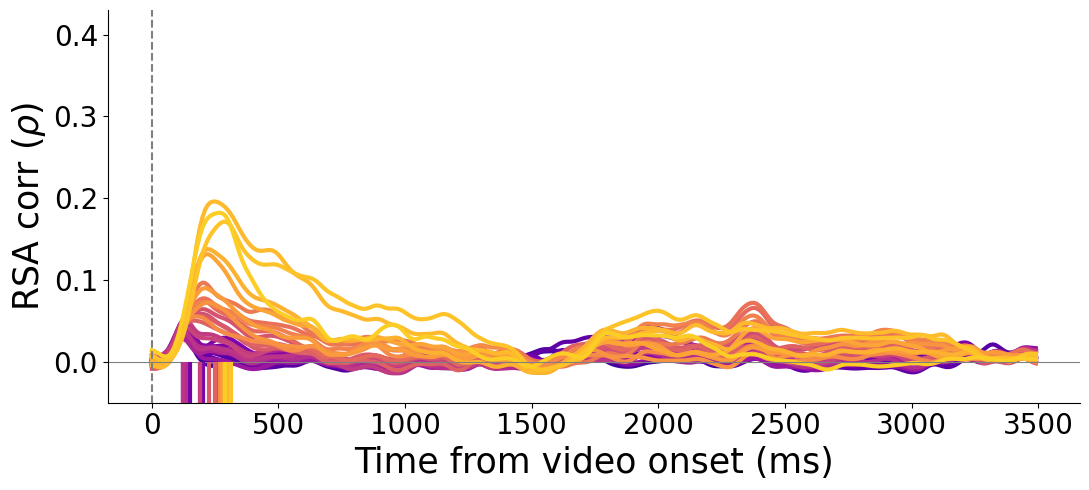

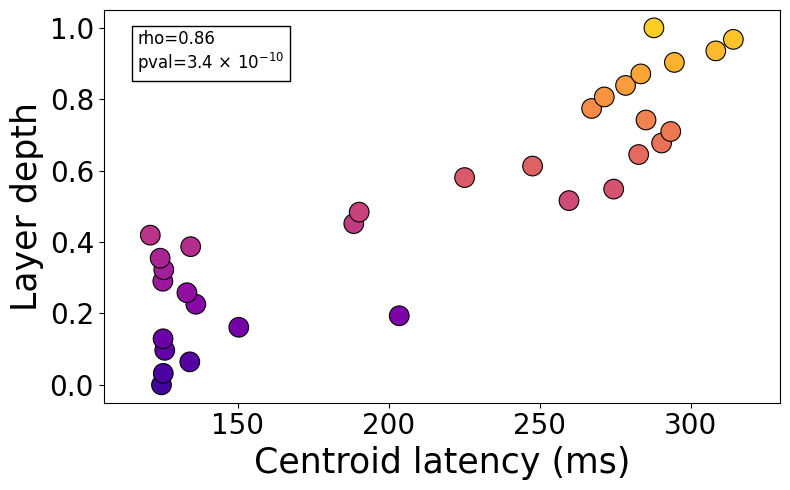

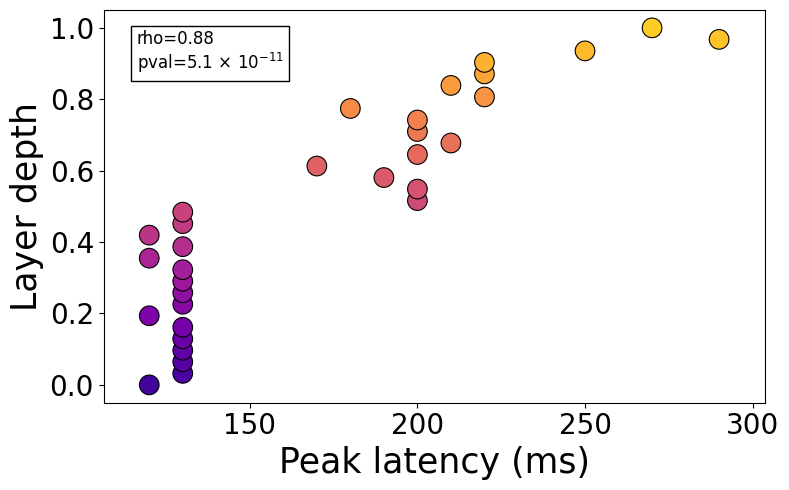

In [ ]:
first_frame_onset_ms = 0
first_window_start_ms, first_window_end_ms = (
    cfg.first_frame_latency_window_ms
)
video_similarity_time_ms = (
    saved_neural_time_ms.copy()
)
first_window_mask = (
    (video_similarity_time_ms >= first_window_start_ms)
    & (video_similarity_time_ms < first_window_end_ms)
)
if not first_window_mask.any():
    raise ValueError('The first-frame latency window contains no samples.')
# end if not first_window_mask.any()
first_frame_index = int(round(
    np.argmin(np.abs(saved_model_time_ms - first_frame_onset_ms))
))
if first_frame_index >= next(iter(video_layer_drsa.values())).shape[1]:
    raise IndexError('The first-frame index is outside the model time axis.')
# end if first_frame_index is outside the model time axis
first_frame_centroid_latency_ms = []
first_frame_peak_latency_ms = []

figure, axis = plt.subplots(figsize=(11, 5))
for layer_index, layer_name in enumerate(video_layer_names):
    layer_similarity = video_layer_drsa[layer_name][:, first_frame_index].copy()
    if cfg.smoothing:
        layer_similarity = gaussian_filter1d(
            layer_similarity, sigma=cfg.smoothing,
        )
    # end if cfg.smoothing

    window_similarity = layer_similarity[first_window_mask]
    window_time_ms = video_similarity_time_ms[first_window_mask]
    centroid_similarity = np.where(
        np.isfinite(window_similarity)
        & (window_similarity > cfg.centroid_similarity_cutoff),
        window_similarity, 0,
    )
    peak_similarity = np.where(
        np.isfinite(window_similarity)
        & (window_similarity > cfg.peak_similarity_cutoff),
        window_similarity, 0,
    )
    if centroid_similarity.sum() == 0:
        centroid_latency_ms = np.nan
    else:
        centroid_time_ms = np.average(
            window_time_ms, weights=centroid_similarity,
        )
        centroid_latency_ms = centroid_time_ms - first_frame_onset_ms
    # end if centroid_similarity.sum() == 0
    if peak_similarity.sum() == 0:
        peak_latency_ms = np.nan
    else:
        peak_time_ms = window_time_ms[np.argmax(peak_similarity)]
        peak_latency_ms = peak_time_ms - first_frame_onset_ms
    # end if peak_similarity.sum() == 0
    first_frame_centroid_latency_ms.append(centroid_latency_ms)
    first_frame_peak_latency_ms.append(peak_latency_ms)
    axis.plot(
        video_similarity_time_ms, layer_similarity,
        color=video_layer_colors[layer_index], linewidth=cfg.linewidth,
    )
    if np.isfinite(centroid_latency_ms):
        axis.vlines(
            centroid_time_ms,
            -cfg.latency_line_centroid_tick_height, 0,
            color=video_layer_colors[layer_index],
            linewidth=cfg.latency_line_centroid_tick_width, zorder=15,
        )
    # end if np.isfinite(centroid_latency_ms)
# end for layer_index, layer_name
axis.axhline(0, color='grey', linewidth=0.8)
axis.axvline(first_frame_onset_ms, linestyle='--', color='grey')
axis.set_ylim(cfg.latency_line_ylim)
axis.set(
    xlabel='Time from video onset (ms)', ylabel=fr'RSA corr ($\rho$)',
)
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
if cfg.fig_save:
    figure.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_vid_first_frame_dRSA_layer_timecourses_'
        f'{cfg.vid_exp_name}.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save
plt.show()

first_frame_latency_summaries = (
    ('centroid', np.asarray(first_frame_centroid_latency_ms)),
    ('peak', np.asarray(first_frame_peak_latency_ms)),
)
for latency_name, latency_values_ms in first_frame_latency_summaries:
    valid_layers = np.isfinite(latency_values_ms)
    if not valid_layers.any():
        raise ValueError(
            f'No finite first-frame {latency_name} latencies.'
        )
    # end if not valid_layers.any()
    finite_latencies_ms = latency_values_ms[valid_layers]
    latency_min_ms = np.min(finite_latencies_ms)
    latency_max_ms = np.max(finite_latencies_ms)
    latency_span_ms = latency_max_ms - latency_min_ms
    x_padding_ms = max(
        cfg.latency_scatter_min_x_padding_ms,
        cfg.latency_scatter_x_padding_fraction * latency_span_ms,
    )
    latency_xlim_ms = (
        latency_min_ms - x_padding_ms,
        latency_max_ms + x_padding_ms,
    )

    figure, axis = plt.subplots(figsize=cfg.latency_scatter_figsize)
    axis.scatter(
        latency_values_ms[valid_layers], video_layer_depths[valid_layers],
        c=video_layer_colors[valid_layers], s=cfg.latency_scatter_size,
        edgecolors=cfg.latency_scatter_edge_color,
        linewidths=cfg.latency_scatter_edge_width,
    )
    if valid_layers.sum() >= 2:
        rho_result = spearmanr(
            finite_latencies_ms, video_layer_depths[valid_layers],
        )
        if np.isfinite(rho_result.pvalue):
            pval_str = f'{rho_result.pvalue:.1e}'
            mantissa, exponent = pval_str.split('e')
            exponent = int(exponent)
            stats_label = (
                f'rho={rho_result.statistic:.2f}\n'
                f'pval={mantissa} × 10$^{{{exponent}}}$'
            )
        else:
            stats_label = f'rho={rho_result.statistic:.2f}\npval=nan'
        # end if np.isfinite(rho_result.pvalue)
    else:
        stats_label = 'rho=nan\npval=nan'
    # end if valid_layers.sum() >= 2
    axis.text(
        0.05, 0.95, stats_label, transform=axis.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='black'),
        fontsize=cfg.latency_scatter_stats_fontsize, zorder=20,
    )
    axis.axvline(0, color='0.6', linewidth=1, linestyle='--')
    axis.set_yticks(cfg.latency_scatter_y_ticks)
    axis.set(
        xlabel=f'{latency_name.capitalize()} latency (ms)',
        ylabel='Layer depth', ylim=(-0.05, 1.05), xlim=latency_xlim_ms,
    )
    axis.locator_params(axis='x', nbins=cfg.latency_scatter_n_ticks)
    axis.tick_params(axis='both', labelsize=cfg.ticks_size)
    axis.xaxis.label.set_size(cfg.label_size)
    axis.yaxis.label.set_size(cfg.label_size)
    axis.spines['top'].set_visible(True)
    axis.spines['right'].set_visible(True)
    figure.tight_layout()

    if cfg.fig_save:
        figure.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_vid_first_frame_dRSA_{latency_name}_'
            f'latency_by_layer_{cfg.vid_exp_name}.pdf',
        )
    # end if cfg.fig_save

    plt.show()
# end for latency_name, latency_values_ms

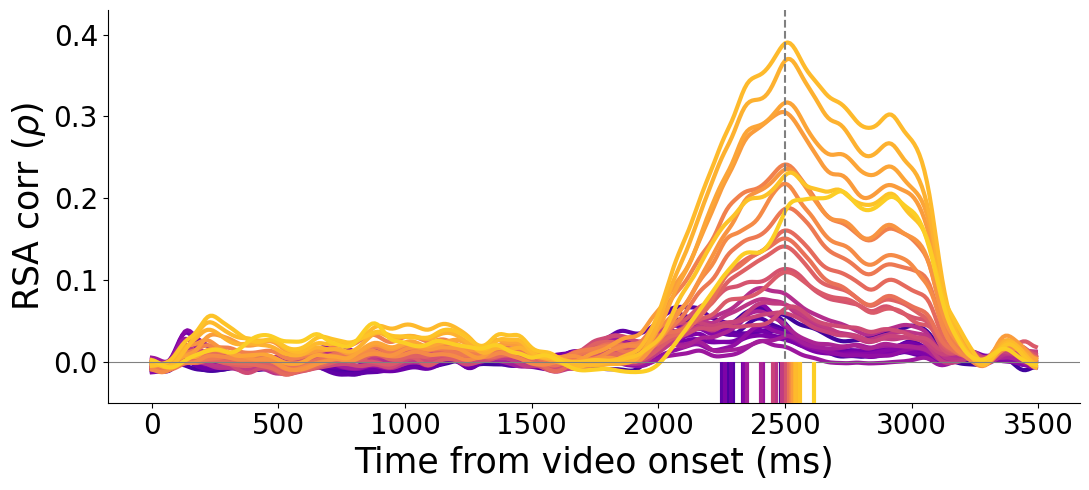

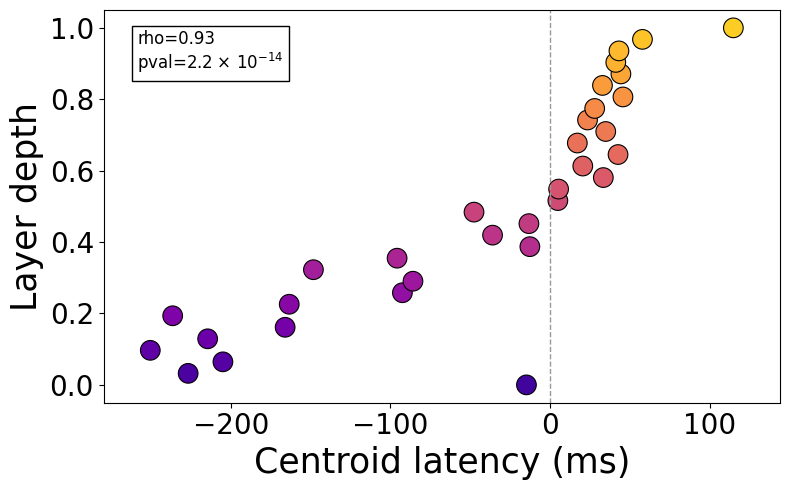

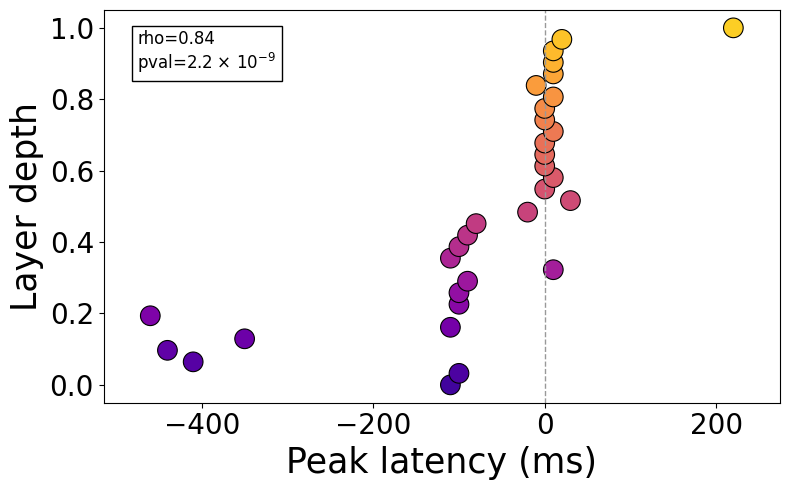

In [ ]:
last_frame_onset_ms = cfg.last_frame_onset_ms
last_window_start_ms, last_window_end_ms = (
    cfg.last_frame_latency_window_ms
)
video_similarity_time_ms = saved_neural_time_ms.copy()
last_window_mask = (
    (video_similarity_time_ms >= last_window_start_ms)
    & (video_similarity_time_ms < last_window_end_ms)
)
if not last_window_mask.any():
    raise ValueError('The last-frame latency window contains no samples.')
# end if not last_window_mask.any()
last_frame_index = int(
    np.argmin(np.abs(saved_model_time_ms - last_frame_onset_ms))
)
if last_frame_index >= next(iter(video_layer_drsa.values())).shape[1]:
    raise IndexError('The last-frame index is outside the model time axis.')
# end if last_frame_index is outside the model time axis
last_frame_centroid_latency_ms = []
last_frame_peak_latency_ms = []

figure, axis = plt.subplots(figsize=(11, 5))
for layer_index, layer_name in enumerate(video_layer_names):
    layer_similarity = video_layer_drsa[layer_name][:, last_frame_index].copy()
    if cfg.smoothing:
        layer_similarity = gaussian_filter1d(
            layer_similarity, sigma=cfg.smoothing,
        )
    # end if cfg.smoothing

    window_similarity = layer_similarity[last_window_mask]
    window_time_ms = video_similarity_time_ms[last_window_mask]
    centroid_similarity = np.where(
        np.isfinite(window_similarity)
        & (window_similarity > cfg.centroid_similarity_cutoff),
        window_similarity, 0,
    )
    peak_similarity = np.where(
        np.isfinite(window_similarity)
        & (window_similarity > cfg.peak_similarity_cutoff),
        window_similarity, 0,
    )
    if centroid_similarity.sum() == 0:
        centroid_latency_ms = np.nan
    else:
        centroid_time_ms = np.average(
            window_time_ms, weights=centroid_similarity,
        )
        centroid_latency_ms = centroid_time_ms - last_frame_onset_ms
    # end if centroid_similarity.sum() == 0
    if peak_similarity.sum() == 0:
        peak_latency_ms = np.nan
    else:
        peak_time_ms = window_time_ms[np.argmax(peak_similarity)]
        peak_latency_ms = peak_time_ms - last_frame_onset_ms
    # end if peak_similarity.sum() == 0
    last_frame_centroid_latency_ms.append(centroid_latency_ms)
    last_frame_peak_latency_ms.append(peak_latency_ms)
    axis.plot(
        video_similarity_time_ms, layer_similarity,
        color=video_layer_colors[layer_index], linewidth=cfg.linewidth,
    )
    if np.isfinite(centroid_latency_ms):
        axis.vlines(
            centroid_time_ms,
            -cfg.latency_line_centroid_tick_height, 0,
            color=video_layer_colors[layer_index],
            linewidth=cfg.latency_line_centroid_tick_width, zorder=15,
        )
    # end if np.isfinite(centroid_latency_ms)
# end for layer_index, layer_name
axis.axhline(0, color='grey', linewidth=0.8)
axis.axvline(last_frame_onset_ms, linestyle='--', color='grey')
axis.set_ylim(cfg.latency_line_ylim)
axis.set(
    xlabel='Time from video onset (ms)', ylabel=fr'RSA corr ($\rho$)',
)
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
figure.tight_layout()
if cfg.fig_save:
    figure.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_vid_last_frame_dRSA_layer_timecourses_'
        f'{cfg.vid_exp_name}.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save
plt.show()

last_frame_latency_summaries = (
    ('centroid', np.asarray(last_frame_centroid_latency_ms)),
    ('peak', np.asarray(last_frame_peak_latency_ms)),
)
for latency_name, latency_values_ms in last_frame_latency_summaries:
    valid_layers = np.isfinite(latency_values_ms)
    if not valid_layers.any():
        raise ValueError(
            f'No finite last-frame {latency_name} latencies.'
        )
    # end if not valid_layers.any()
    finite_latencies_ms = latency_values_ms[valid_layers]
    latency_min_ms = np.min(finite_latencies_ms)
    latency_max_ms = np.max(finite_latencies_ms)
    latency_span_ms = latency_max_ms - latency_min_ms
    x_padding_ms = max(
        cfg.latency_scatter_min_x_padding_ms,
        cfg.latency_scatter_x_padding_fraction * latency_span_ms,
    )
    latency_xlim_ms = (
        latency_min_ms - x_padding_ms,
        latency_max_ms + x_padding_ms,
    )

    figure, axis = plt.subplots(figsize=cfg.latency_scatter_figsize)
    axis.scatter(
        latency_values_ms[valid_layers], video_layer_depths[valid_layers],
        c=video_layer_colors[valid_layers], s=cfg.latency_scatter_size,
        edgecolors=cfg.latency_scatter_edge_color,
        linewidths=cfg.latency_scatter_edge_width,
    )
    if valid_layers.sum() >= 2:
        rho_result = spearmanr(
            finite_latencies_ms, video_layer_depths[valid_layers],
        )
        if np.isfinite(rho_result.pvalue):
            pval_str = f'{rho_result.pvalue:.1e}'
            mantissa, exponent = pval_str.split('e')
            exponent = int(exponent)
            stats_label = (
                f'rho={rho_result.statistic:.2f}\n'
                f'pval={mantissa} × 10$^{{{exponent}}}$'
            )
        else:
            stats_label = f'rho={rho_result.statistic:.2f}\npval=nan'
        # end if np.isfinite(rho_result.pvalue)
    else:
        stats_label = 'rho=nan\npval=nan'
    # end if valid_layers.sum() >= 2
    axis.text(
        0.05, 0.95, stats_label, transform=axis.transAxes,
        ha='left', va='top',
        bbox=dict(facecolor='white', edgecolor='black'),
        fontsize=cfg.latency_scatter_stats_fontsize, zorder=20,
    )
    axis.axvline(0, color='0.6', linewidth=1, linestyle='--')
    axis.set_yticks(cfg.latency_scatter_y_ticks)
    axis.set(
        xlabel=f'{latency_name.capitalize()} latency (ms)',
        ylabel='Layer depth', ylim=(-0.05, 1.05), xlim=latency_xlim_ms,
    )
    axis.locator_params(axis='x', nbins=cfg.latency_scatter_n_ticks)
    axis.tick_params(axis='both', labelsize=cfg.ticks_size)
    axis.xaxis.label.set_size(cfg.label_size)
    axis.yaxis.label.set_size(cfg.label_size)
    axis.spines['top'].set_visible(True)
    axis.spines['right'].set_visible(True)
    figure.tight_layout()

    if cfg.fig_save:
        figure.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_vid_last_frame_dRSA_{latency_name}_'
            f'latency_by_layer_{cfg.vid_exp_name}.pdf',
        )
    # end if cfg.fig_save

    plt.show()
# end for latency_name, latency_values_ms

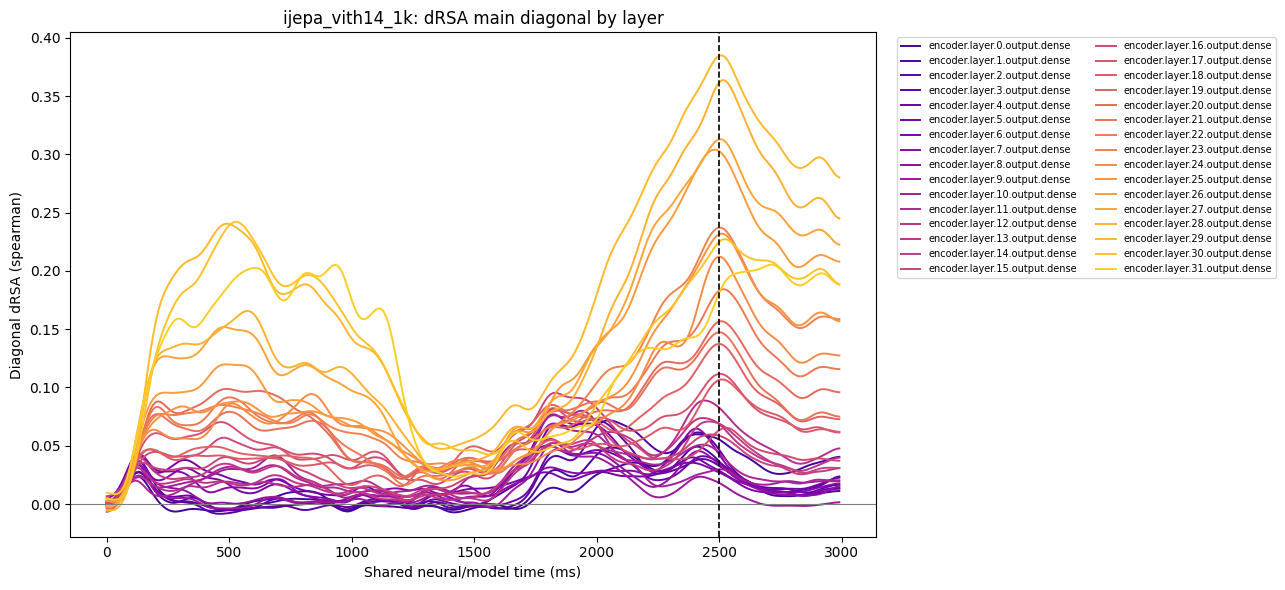

In [ ]:
# Extract the main diagonal, where neural time equals model time.
diagonal_length = min(next(iter(video_layer_drsa.values())).shape)
diagonal_time_ms = saved_neural_time_ms[:diagonal_length]

video_layer_diagonals = []
for layer_name in video_layer_names:
    layer_diagonal = np.diagonal(video_layer_drsa[layer_name]).copy()
    if layer_diagonal.shape[0] != diagonal_length:
        raise ValueError("dRSA layers have inconsistent diagonal lengths.")
    # end if layer_diagonal.shape[0]
    video_layer_diagonals.append(layer_diagonal)
# end for layer_name
video_layer_diagonals = np.stack(video_layer_diagonals, axis=0)


fig, ax = plt.subplots(figsize=(13, 6))
for layer_index, (layer_name, layer_diagonal) in enumerate(
    zip(video_layer_names, video_layer_diagonals)
):
    layer_diagonal = gaussian_filter1d(layer_diagonal, sigma=4)
    ax.plot(
        diagonal_time_ms,
        layer_diagonal,
        color=video_layer_colors[layer_index],
        linewidth=1.4,
        label=layer_name,
    )
# end for layer_index

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(
    last_frame_ms, color="black", linestyle="--", linewidth=1.2,
)
ax.set(
    xlabel="Shared neural/model time (ms)",
    ylabel=f"Diagonal dRSA ({configured_rsa_metric})",
    title=(
        f"{cfg.model_name}: "
        "dRSA main diagonal by layer"
    ),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
fig.tight_layout()


In [ ]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs
# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(10,100), model_idx=range(10,100), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("time from video onset (ms)")
# plt.title("From 0 to 1000ms")


In [ ]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(80,250), model_idx=range(80,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


In [ ]:
# max_lag = 30
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(200,250), model_idx=range(200,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


# Raw lagged correlation between image and video neural activity

In [ ]:
from useful_stuff.general_utils.utils import mean_centering

# Remove each channel's stimulus-generic response profile (shared across nearly
# every stimulus) so the pattern correlation reflects stimulus-specific content.
video_centered = mean_centering(video_ts.array, axis=2)
image_centered = mean_centering(image_ts.array, axis=2)

running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_centered[:,:,i], cfg.new_fs)
    i = TimeSeries(image_centered[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)
running_sum = running_sum / video_ts.shape()[2]

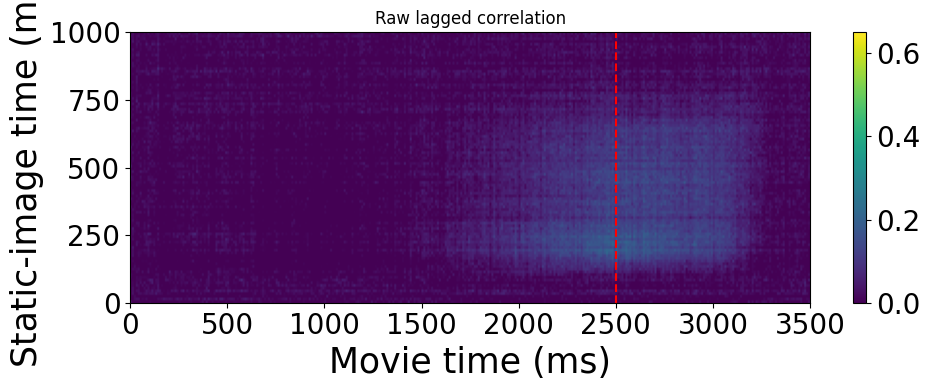

In [ ]:
# Put the longer movie response on x so the matrix reads horizontally.
dynamic_time_end_ms = running_sum.shape[0] * 1000 / video_ts.get_fs()
static_time_end_ms = running_sum.shape[1] * 1000 / image_ts.get_fs()
static_dynamic_extent_ms = (
    0, dynamic_time_end_ms, static_time_end_ms, 0,
)

figure, axis = plt.subplots(figsize=cfg.static_dynamic_matrix_figsize)
image = axis.imshow(
    running_sum.T, aspect='auto', origin='lower',
    cmap=cfg.static_dynamic_matrix_cmap,
    vmin=cfg.static_dynamic_matrix_vmin,
    vmax=cfg.static_dynamic_matrix_vmax,
    extent=(0, dynamic_time_end_ms, 0, static_time_end_ms),
)
axis.axvline(cfg.last_frame_onset_ms, linestyle='--', color='red')
axis.set(
    title='Raw lagged correlation',
    xlabel='Movie time (ms)', ylabel='Static-image time (ms)',
)
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
colorbar = figure.colorbar(image, ax=axis)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
figure.tight_layout()

In [ ]:
from useful_stuff.general_utils.utils import mean_centering
running_sum = None

n = 100
rng = np.random.default_rng(1)

left = rng.permutation(n)
right = rng.permutation(n)

pairs = np.column_stack([left, right])

# Same stimulus-generic centering as the matched-pairing cell above.
video_centered = mean_centering(video_ts.array, axis=2)
image_centered = mean_centering(image_ts.array, axis=2)

for k in range(n):
    v = TimeSeries(video_centered[:,:,pairs[k,0]], cfg.new_fs)
    i = TimeSeries(image_centered[:,:,pairs[k,1]], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i, metric="correlation")
    else:
        running_sum += v.lagged_corr(i, metric="correlation")
running_sum = running_sum / video_ts.shape()[2]

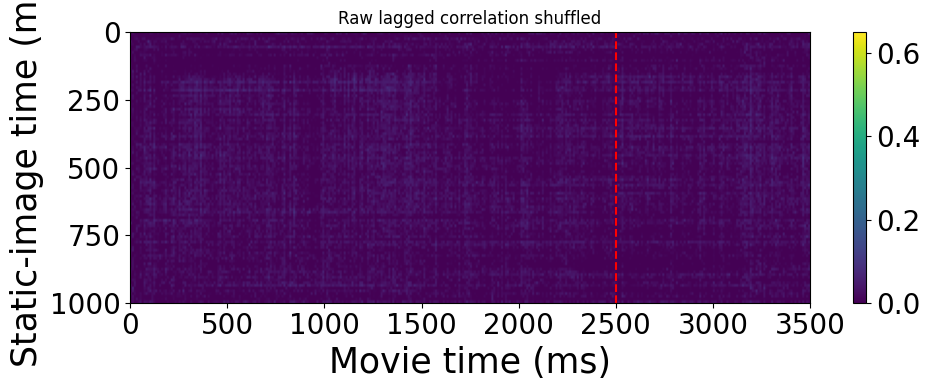

In [ ]:
# Keep the shuffled control in the same horizontal millisecond layout.
dynamic_time_end_ms = running_sum.shape[0] * 1000 / video_ts.get_fs()
static_time_end_ms = running_sum.shape[1] * 1000 / image_ts.get_fs()
static_dynamic_extent_ms = (
    0, dynamic_time_end_ms, static_time_end_ms, 0,
)

figure, axis = plt.subplots(figsize=cfg.static_dynamic_matrix_figsize)
image = axis.imshow(
    running_sum.T, aspect='auto', origin='upper',
    cmap=cfg.static_dynamic_matrix_cmap,
    vmin=cfg.static_dynamic_matrix_vmin,
    vmax=cfg.static_dynamic_matrix_vmax,
    extent=static_dynamic_extent_ms,
)
axis.axvline(cfg.last_frame_onset_ms, linestyle='--', color='red')
axis.set(
    title='Raw lagged correlation shuffled',
    xlabel='Movie time (ms)', ylabel='Static-image time (ms)',
)
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
colorbar = figure.colorbar(image, ax=axis)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
figure.tight_layout()

# Image-movie Dynamic RSA

In [ ]:
from scipy.spatial.distance import squareform
from useful_stuff.general_utils import spearman
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric=spearman,
)
drsa.compute_both_RDM_timeseries(video_ts, image_ts)
# m_ts = []
# for RDM in drsa.signal_RDM_timeseries:
#     m = squareform(RDM)
#     m = m[np.ix_(pairs[:, 0], pairs[:, 0])]   # permute rows and columns
#     m = m[np.triu_indices_from(m, k=1)]       # extract upper triangle
#     m_ts.append(m)
# m_ts = TimeSeries(m_ts, 100)
# drsa.set_RDM_timeseries(m_ts, "signal")
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


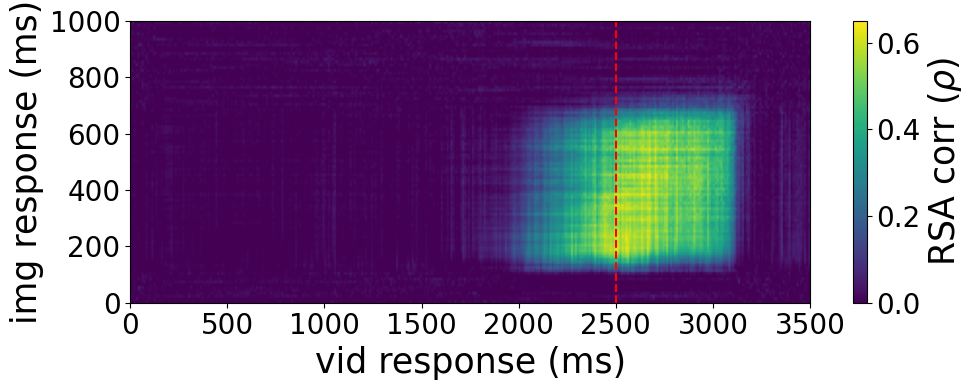

In [ ]:
# Display movie time horizontally and label both axes in milliseconds.
dynamic_time_end_ms = corr_mat.shape[0] * 1000 / video_ts.get_fs()
static_time_end_ms = corr_mat.shape[1] * 1000 / image_ts.get_fs()
static_dynamic_extent_ms = (
    0, dynamic_time_end_ms, static_time_end_ms, 0,
)

figure, axis = plt.subplots(figsize=cfg.static_dynamic_matrix_figsize)
image = axis.imshow(
    corr_mat.T,
    cmap=cfg.static_dynamic_matrix_cmap,
    vmin=cfg.static_dynamic_matrix_vmin,
    vmax=cfg.static_dynamic_matrix_vmax,
    aspect='auto',
    origin='lower',
    extent=(0, dynamic_time_end_ms, 0, static_time_end_ms),

)
axis.axvline(cfg.last_frame_onset_ms, linestyle='--', color='red')
axis.set(
    xlabel='vid response (ms)', ylabel='img response (ms)',
)

axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
colorbar = figure.colorbar(image, ax=axis)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
colorbar.set_label(
    fr'RSA corr ($\rho$)', fontsize=cfg.label_size,
)
figure.tight_layout()
if cfg.fig_save:
    figure.savefig(f"{cfg.figs_dir}/{cfg.monkey_name}_{cfg.vid_exp_name}_static-dyn_dRSA_mat_{cfg.signal_RDM_metric}.pdf")

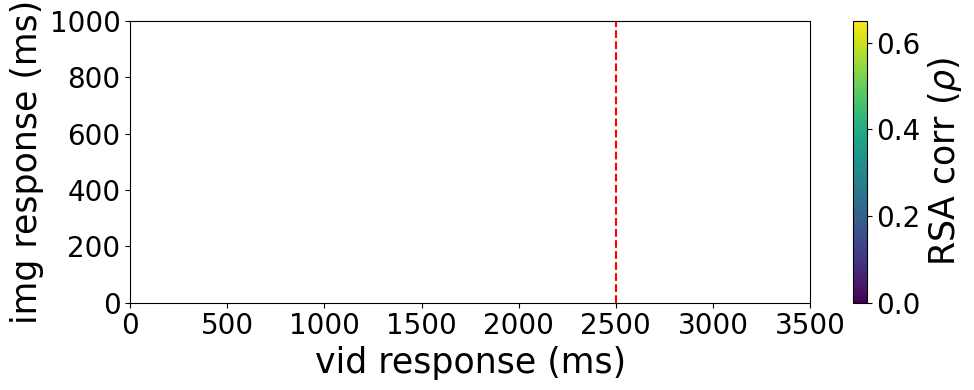

In [ ]:
# Reproduce the static-dynamic matrix as a blank hypothesis canvas.
dynamic_time_end_ms = corr_mat.shape[0] * 1000 / video_ts.get_fs()
static_time_end_ms = corr_mat.shape[1] * 1000 / image_ts.get_fs()
blank_hypothesis_matrix = np.full(corr_mat.T.shape, np.nan)

# NaN values make only the matrix interior white; the colorbar retains the
# configured static-dynamic scale for adding hypothesis annotations later.
hypothesis_cmap = plt.get_cmap(
    cfg.static_dynamic_matrix_cmap,
).copy()
hypothesis_cmap.set_bad('white')
hypothesis_vmin = (
    np.nanmin(corr_mat)
    if cfg.static_dynamic_matrix_vmin is None
    else cfg.static_dynamic_matrix_vmin
)
hypothesis_vmax = (
    np.nanmax(corr_mat)
    if cfg.static_dynamic_matrix_vmax is None
    else cfg.static_dynamic_matrix_vmax
)

figure, axis = plt.subplots(figsize=cfg.static_dynamic_matrix_figsize)
image = axis.imshow(
    blank_hypothesis_matrix,
    cmap=hypothesis_cmap,
    vmin=hypothesis_vmin, vmax=hypothesis_vmax,
    aspect='auto', origin='lower',
    extent=(0, dynamic_time_end_ms, 0, static_time_end_ms),
)
axis.axvline(cfg.last_frame_onset_ms, linestyle='--', color='red')
axis.set(xlabel='vid response (ms)', ylabel='img response (ms)')
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
colorbar = figure.colorbar(image, ax=axis)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
colorbar.set_label(
    fr'RSA corr ($\rho$)', fontsize=cfg.label_size,
)
figure.tight_layout()

if cfg.fig_save:
    figure.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_'
        f'static-dyn_dRSA_mat_hypothesis_blank_'
        f'{cfg.signal_RDM_metric}.pdf',
    )
# end if cfg.fig_save


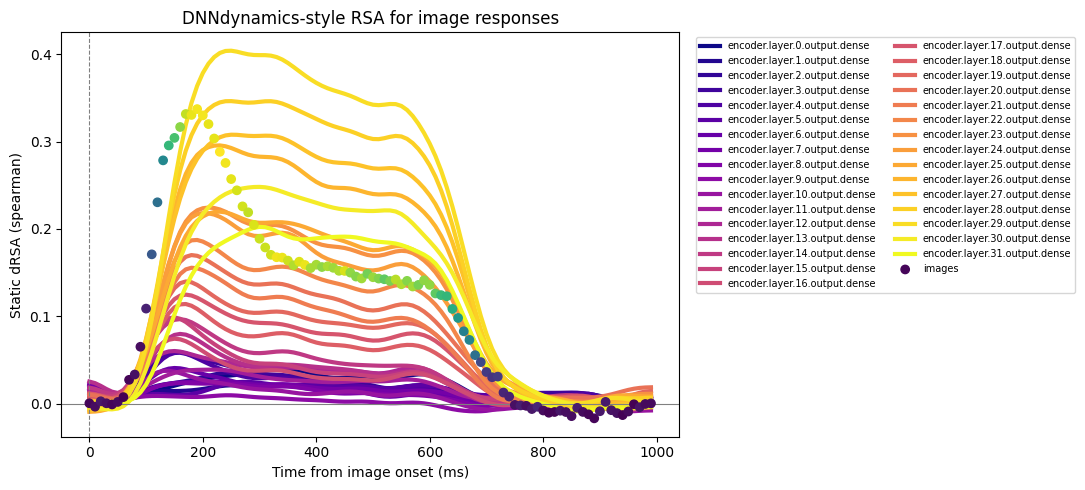

In [ ]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
static_to_dynamic_corr = corr_mat[240:260, :].mean(axis=0)
image_trace = np.mean(image_ts.array[:, :, :], axis=(0,2)).T
points = ax.scatter(
    image_time_ms, image_trace,
    c=static_to_dynamic_corr, cmap="viridis", label="images",zorder=5
)
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
# ax.colorbar(points, label="dRSA corr (dynamic rows 250:270, avg)")
# plt.legend()

In [ ]:
mat, lp = drsa.signal_RDM_timeseries.autocorr()
mat[200:300, 200:300].shape

(100, 100)

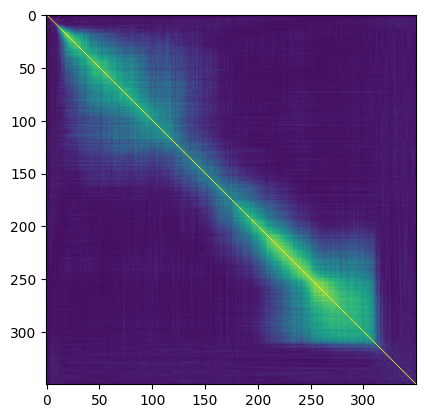

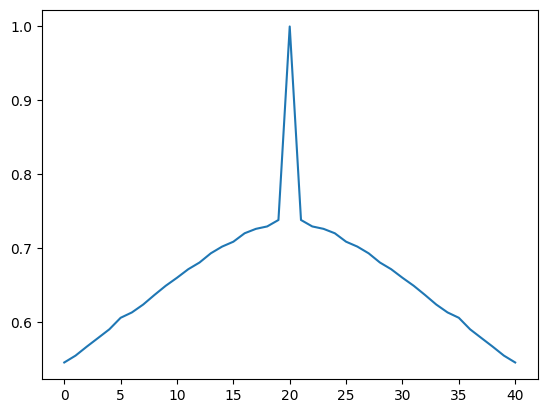

In [ ]:
plt.imshow(mat)
plt.figure()
plt.plot(get_lagplot(mat[200:300, 200:300], max_lag=20))

array([[-0.00658203,  0.01066351, -0.00797832, ..., -0.00511012,
         0.01600161,  0.00048261],
       [ 0.00700813,  0.01811255, -0.00053759, ..., -0.01042169,
         0.01525984,  0.01184326],
       [ 0.0037427 ,  0.02415267, -0.00105926, ..., -0.01849612,
         0.00864652,  0.00578615],
       ...,
       [-0.02044356,  0.02839036,  0.02094645, ...,  0.02500322,
         0.00643245, -0.01698616],
       [-0.00119081,  0.02137597,  0.01575756, ...,  0.01561577,
         0.01239532, -0.01684771],
       [-0.00842684,  0.01063002, -0.00531662, ...,  0.01623447,
        -0.01789046,  0.00137367]], shape=(100, 100))

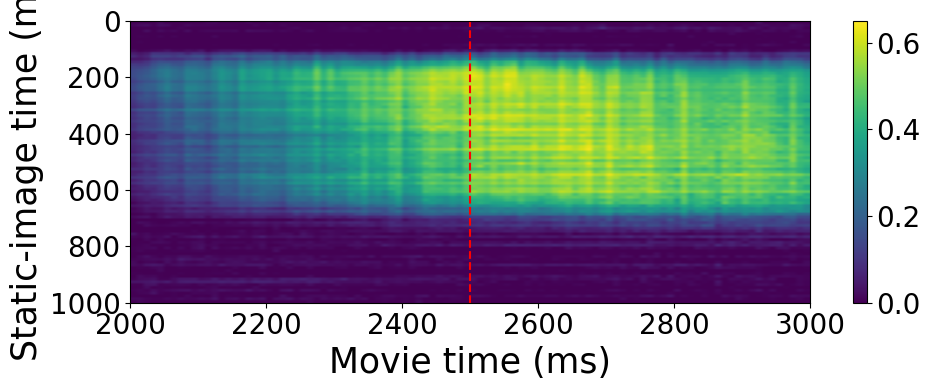

In [ ]:
# Inspect the late movie window without reverting to sample-index axes.
dynamic_window_ms = (2000, 3000)
dynamic_window_indices = np.rint(
    np.asarray(dynamic_window_ms) * video_ts.get_fs() / 1000,
).astype(int)
dynamic_window = corr_mat[
    dynamic_window_indices[0]:dynamic_window_indices[1], :
]
static_time_end_ms = dynamic_window.shape[1] * 1000 / image_ts.get_fs()

figure, axis = plt.subplots(figsize=cfg.static_dynamic_matrix_figsize)
image = axis.imshow(
    dynamic_window.T, aspect='auto', origin='upper',
    cmap=cfg.static_dynamic_matrix_cmap,
    vmin=cfg.static_dynamic_matrix_vmin,
    vmax=cfg.static_dynamic_matrix_vmax,
    extent=(
        dynamic_window_ms[0], dynamic_window_ms[1],
        static_time_end_ms, 0,
    ),
)
axis.axvline(cfg.last_frame_onset_ms, linestyle='--', color='red')
axis.set(
    xlabel='Movie time (ms)', ylabel='Static-image time (ms)',
)
axis.tick_params(axis='both', labelsize=cfg.ticks_size)
axis.xaxis.label.set_size(cfg.label_size)
axis.yaxis.label.set_size(cfg.label_size)
colorbar = figure.colorbar(image, ax=axis)
colorbar.ax.tick_params(labelsize=cfg.ticks_size)
figure.tight_layout()
dynamic_window

Text(0.5, 1.0, 'Static to dynamic lagplot')

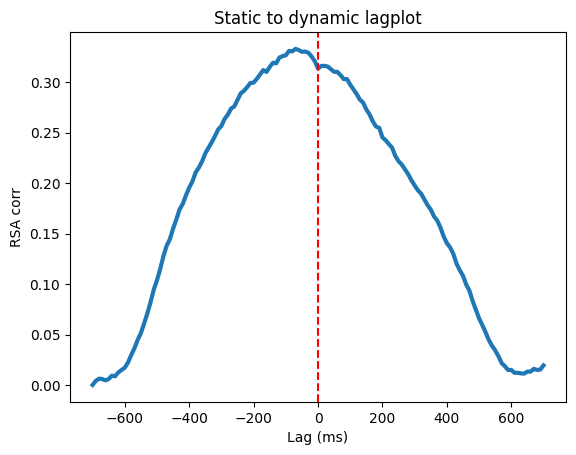

In [ ]:
max_lag = 70
lagplot = get_lagplot(corr_mat[250:340, 10:100], max_lag=max_lag)
lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

plt.plot(lags, lagplot, linewidth=cfg.linewidth)
plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Lag (ms)")
plt.ylabel("RSA corr")
plt.title("Static to dynamic lagplot")


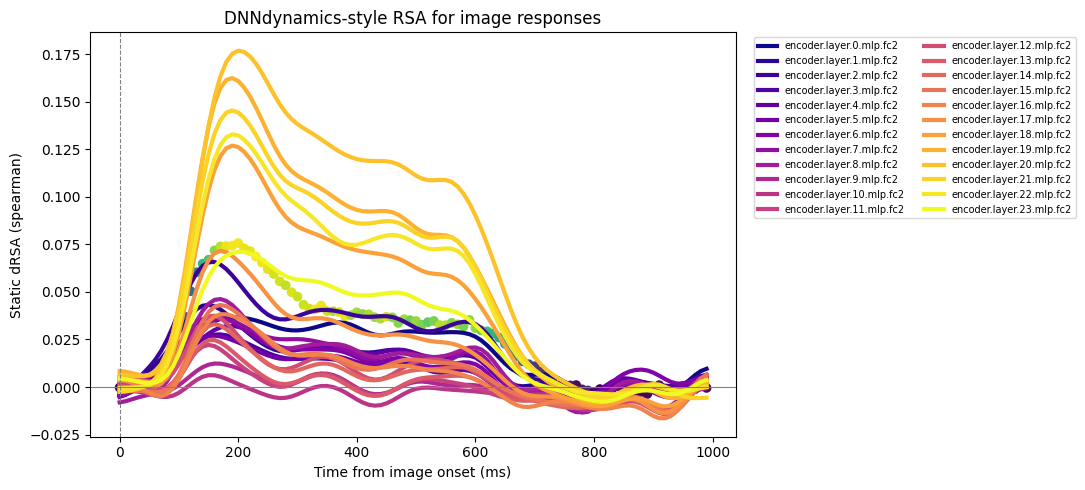

In [ ]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
static_to_dynamic_corr = corr_mat[240:260, :].mean(axis=0)
image_trace = np.mean(image_ts.array[:, :, :], axis=(0,2)).T
points = ax.scatter(
    image_time_ms, image_trace,
    c=static_to_dynamic_corr, cmap="viridis", label="images",
)
# ax.colorbar(points, label="dRSA corr (dynamic rows 250:270, avg)")
# plt.legend()

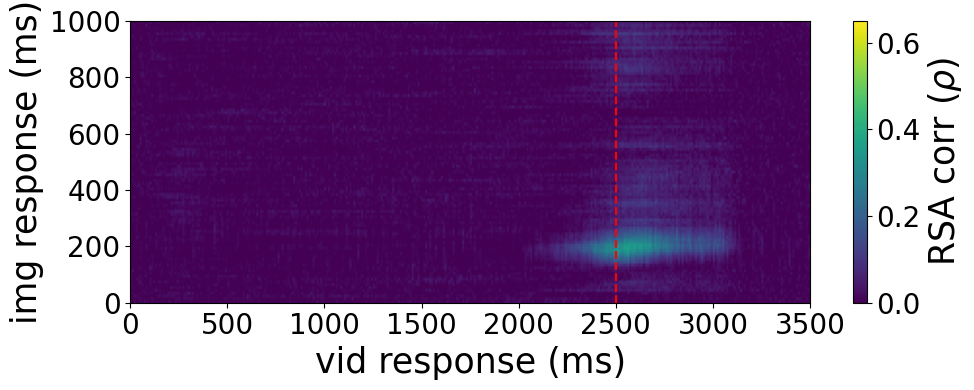

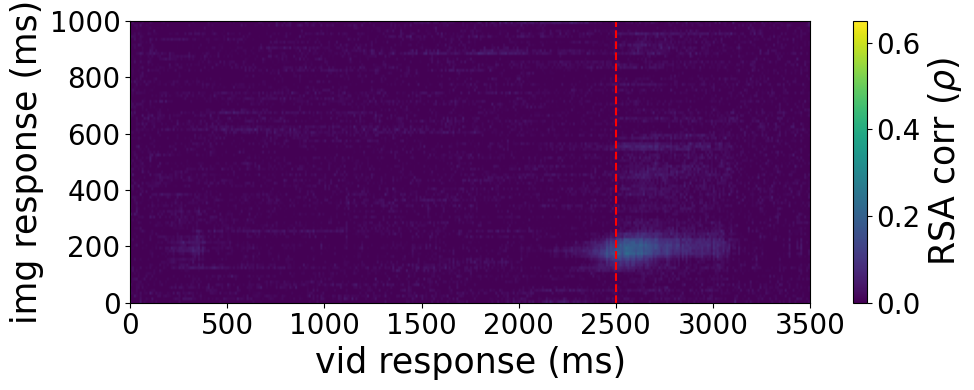

In [ ]:
# Remove each earlier static response from the time-resolved last-frame response.
delayed_static_by_condition = {
    '2000ms': image_2000ms_ts,
    '2250ms': image_2250ms_ts,
}
target_array = image_ts.get_array()
target_shape = target_array.shape
residual_similarity_by_condition = {}

for delayed_condition in cfg.residual_conditions:
    if delayed_condition not in delayed_static_by_condition:
        raise ValueError(
            f'Unsupported residual condition: {delayed_condition!r}.'
        )
    # end if delayed_condition

    delayed_ts = delayed_static_by_condition[delayed_condition]
    if delayed_ts.get_fs() != image_ts.get_fs():
        raise ValueError('Static responses have different sampling rates.')
    # end if delayed_ts.get_fs()

    # Embed adjacent delayed-condition samples while keeping stimuli independent.
    predictor_array = delayed_ts.delay_embeddings(
        lags=cfg.residual_delay_embedding_lags, pad_mode='edge',
    ).get_array()
    predictor_flat_ts = TimeSeries(
        predictor_array.reshape(predictor_array.shape[0], -1),
        fs=image_ts.get_fs(),
    )
    target_flat_ts = TimeSeries(
        target_array.reshape(target_shape[0], -1), fs=image_ts.get_fs(),
    )
    regression_model = dyn_linear_encoding(
        regression_type=cfg.residual_regression_type,
        cv_type='same', max_lag=0,
    )
    residual_flat_ts = regression_model.pointwise_regress_out(
        predictor_flat_ts, target_flat_ts,
    )
    residual_static_ts = TimeSeries(
        residual_flat_ts.get_array().reshape(target_shape),
        fs=image_ts.get_fs(),
    )

    residual_drsa = dRSA(
        signal_RDM_metric=cfg.signal_RDM_metric,
        model_RDM_metric=cfg.signal_RDM_metric,
        RSA_metric='correlation',
    )
    residual_drsa.compute_both_RDM_timeseries(video_ts, residual_static_ts)
    residual_similarity_by_condition[delayed_condition] = (
        residual_drsa.compute_dRSA()
    )
# end for delayed_condition

static_time_end_ms = len(image_ts) * 1000 / image_ts.get_fs()
dynamic_time_end_ms = len(video_ts) * 1000 / video_ts.get_fs()
for delayed_condition in cfg.residual_conditions:
    figure, axis = plt.subplots(
        figsize=cfg.static_dynamic_matrix_figsize,
    )
    image = axis.imshow(
        residual_similarity_by_condition[delayed_condition].T,
        aspect='auto', origin='lower',
        cmap=cfg.static_dynamic_matrix_cmap,
        vmin=cfg.static_dynamic_matrix_vmin,
        vmax=cfg.static_dynamic_matrix_vmax,
        extent=(
            0, dynamic_time_end_ms, 0, static_time_end_ms, 
        ),
    )
    axis.set(
        xlabel='Movie time (ms)',
        ylabel='Residual static-image time (ms)',
    )
    axis.tick_params(axis='both', labelsize=cfg.ticks_size)
    axis.xaxis.label.set_size(cfg.label_size)
    axis.yaxis.label.set_size(cfg.label_size)
    colorbar = figure.colorbar(image, ax=axis)

    colorbar.ax.tick_params(labelsize=cfg.ticks_size)
    axis.axvline(
        cfg.last_frame_onset_ms, linestyle='--', color='red',
    )
    axis.set(
       xlabel='vid response (ms)', ylabel='img response (ms)',
    )
    colorbar.set_label(
        fr'RSA corr ($\rho$)', fontsize=cfg.label_size,
    )
    figure.tight_layout()
    if cfg.fig_save:
        figure.savefig(f"{cfg.figs_dir}/{cfg.monkey_name}_{cfg.vid_exp_name}_static-dyn_dRSA_mat_{cfg.signal_RDM_metric}_ro_{delayed_condition}.pdf")
# end for delayed_condition


In [ ]:
# Resolve the saved split-half results for the active experiment and channels.
if cfg.split_half_results_dir is not None:
    split_half_results_dir = Path(cfg.split_half_results_dir).expanduser()
else:
    split_half_results_root = (
        PROJECT_ROOT / 'results' / 'static_dynamic_all_frame_timings'
        / f'{cfg.vid_exp_name}_vs_{cfg.img_exp_name}'
    )
    if cfg.use_reliable_channels:
        channel_selection = 'reliable_channels'
        if cfg.good_channels is not None:
            first_channel, last_channel = cfg.good_channels
            channel_selection += f'_{first_channel}to{last_channel}'
        # end if cfg.good_channels is not None
        if cfg.top_k is not None:
            channel_selection += f'_top_{cfg.top_k}'
        # end if cfg.top_k is not None
    elif cfg.good_channels is not None:
        first_channel, last_channel = cfg.good_channels
        channel_selection = f'channels_{first_channel}to{last_channel}'
    elif cfg.top_k is not None:
        channel_selection = f'top_{cfg.top_k}'
    else:
        channel_selection = 'all_channels'
    # end if cfg.use_reliable_channels

    channel_results_dir = split_half_results_root / channel_selection
    if cfg.use_reliable_channels and not channel_results_dir.is_dir():
        raise FileNotFoundError(
            'Missing reliable-channel split-half results: '
            f'{channel_results_dir}'
        )
    # end if reliable split-half results are missing
    split_half_results_dir = (
        channel_results_dir
        if channel_results_dir.is_dir()
        else split_half_results_root
    )
# end if cfg.split_half_results_dir is not None

filename_suffix = split_half_filename_suffix(
    cfg.signal_RDM_metric, cfg.split_half_feature_centering,
)
frame_timing = cfg.split_half_frame_timing
result_path = (
    split_half_results_dir
    / f'{frame_timing}{filename_suffix}_results.npz'
)
if not result_path.is_file():
    raise FileNotFoundError(f'Missing split-half result: {result_path}')
# end if not result_path.is_file()
with np.load(result_path, allow_pickle=False) as archive:
    results = {
        result_name: archive[result_name]
        for result_name in archive.files
    }
# end with np.load
saved_rdm_metric = str(results['rdm_metric'].item())
if saved_rdm_metric != cfg.signal_RDM_metric:
    raise ValueError(
        f'Expected RDM metric {cfg.signal_RDM_metric!r}, but '
        f'{result_path} contains {saved_rdm_metric!r}.'
    )
# end if saved_rdm_metric

correction_suffix = (
    'spearman_brown'
    if cfg.split_half_use_spearman_brown
    else 'uncorrected'
)
correction_label = (
    'Spearman–Brown corrected'
    if cfg.split_half_use_spearman_brown
    else 'uncorrected'
)
static_times_ms = results['static_times_ms']
dynamic_times_ms = results['dynamic_times_ms']
start_ms, end_ms = cfg.split_half_static_reference_window_ms
static_reference = (
    (static_times_ms >= start_ms) & (static_times_ms <= end_ms)
)
if not static_reference.any():
    raise ValueError('The static reference window contains no samples.')
# end if not static_reference.any()

# Reduce the static axis to the best static-image match at each movie time.
best_static_dynamic_rsa = np.nanmax(
    results['rsa_lagged_correlation_all_dynamic_trials'][
        :, static_reference
    ],
    axis=1,
)
dynamic_rsa_reliability = results[
    f'dynamic_rsa_self_consistency_mean_{correction_suffix}'
]
reliability_std_key = (
    f'dynamic_rsa_self_consistency_std_{correction_suffix}'
)
if reliability_std_key in results:
    dynamic_rsa_std = results[reliability_std_key]
else:
    # Older archives retain the split repetitions but not their SD.
    dynamic_rsa_splits = results[
        'dynamic_rsa_self_consistency_splits_uncorrected'
    ]
    if cfg.split_half_use_spearman_brown:
        correction_k = cfg.split_half_spearman_brown_k
        dynamic_rsa_splits = (
            correction_k * dynamic_rsa_splits
            / (1 + (correction_k - 1) * dynamic_rsa_splits)
        )
    # end if cfg.split_half_use_spearman_brown
    dynamic_rsa_std = np.nanstd(dynamic_rsa_splits, axis=0)
# end if reliability_std_key in results

# Fix both figures to the same y range so only the added curve changes.
all_plot_values = np.concatenate([
    best_static_dynamic_rsa,
    dynamic_rsa_reliability - dynamic_rsa_std,
    dynamic_rsa_reliability + dynamic_rsa_std,
])
plot_min = min(0, np.nanmin(all_plot_values))
plot_max = max(0, np.nanmax(all_plot_values))
plot_range = plot_max - plot_min
plot_padding = 0.05 * plot_range if plot_range > 0 else 0.05
shared_ylim = (plot_min - plot_padding, plot_max + plot_padding)

# Draw reliability alone first, followed by the two-curve comparison.
plot_specs = (
    ('split_half_reliability', False),
    ('split_half_reliability_and_static_dynamic', True),
)
for filename_label, include_static_dynamic in plot_specs:
    figure, axis = plt.subplots(figsize=cfg.split_half_figsize)
    if include_static_dynamic:
        axis.plot(
            dynamic_times_ms, best_static_dynamic_rsa,
            color=cfg.split_half_static_dynamic_color,
            linewidth=cfg.linewidth,
            label='static–dynamic dRSA corr',
        )
    # end if include_static_dynamic
    axis.plot(
        dynamic_times_ms, dynamic_rsa_reliability,
        color=cfg.split_half_reliability_color,
        linewidth=cfg.linewidth,
        label='split-half RDM reliability',
    )
    axis.fill_between(
        dynamic_times_ms,
        dynamic_rsa_reliability - dynamic_rsa_std,
        dynamic_rsa_reliability + dynamic_rsa_std,
        color=cfg.split_half_reliability_color,
        alpha=cfg.split_half_std_alpha, label='_nolegend_',
    )
    axis.axhline(0, color='0.6', linewidth=1)
    axis.set(
        xlabel='Time from video onset (ms)',
        ylabel=fr'RSA corr ($\rho$)',
        ylim=shared_ylim,
    )
    axis.tick_params(axis='both', labelsize=cfg.ticks_size)
    axis.xaxis.label.set_size(cfg.label_size)
    axis.yaxis.label.set_size(cfg.label_size)
    axis.title.set_size(cfg.label_size)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(fontsize=cfg.split_half_legend_size, loc='lower left')
    axis.axvline(last_frame_ms, linestyle='--', color='red')
    figure.tight_layout()

    if cfg.fig_save:
        figure.savefig(
            f'{cfg.figs_dir}/{cfg.monkey_name}_{cfg.vid_exp_name}_last_frame_'
            f'{filename_label}_{cfg.signal_RDM_metric}.pdf',
        )
    # end if cfg.fig_save

    plt.show()
# end for filename_label, include_static_dynamic
print(f'Loaded split-half results from {split_half_results_dir}')


FileNotFoundError: Missing split-half result: /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_all_frame_timings/baby1_260716to24_vs_baby1_260718to27/last_frame_rdm_cosine_cnt_feat_cnt_results.npz

# Layer depth–latency evolution across movie frames

Loads the layer-wise model–neural RSA matrices saved by `run_static_dynamic_neural_model_rsa.py --parallel`. The 20 panels sample model frames evenly in time and show how each frame's neural similarity latency varies with normalized network depth.

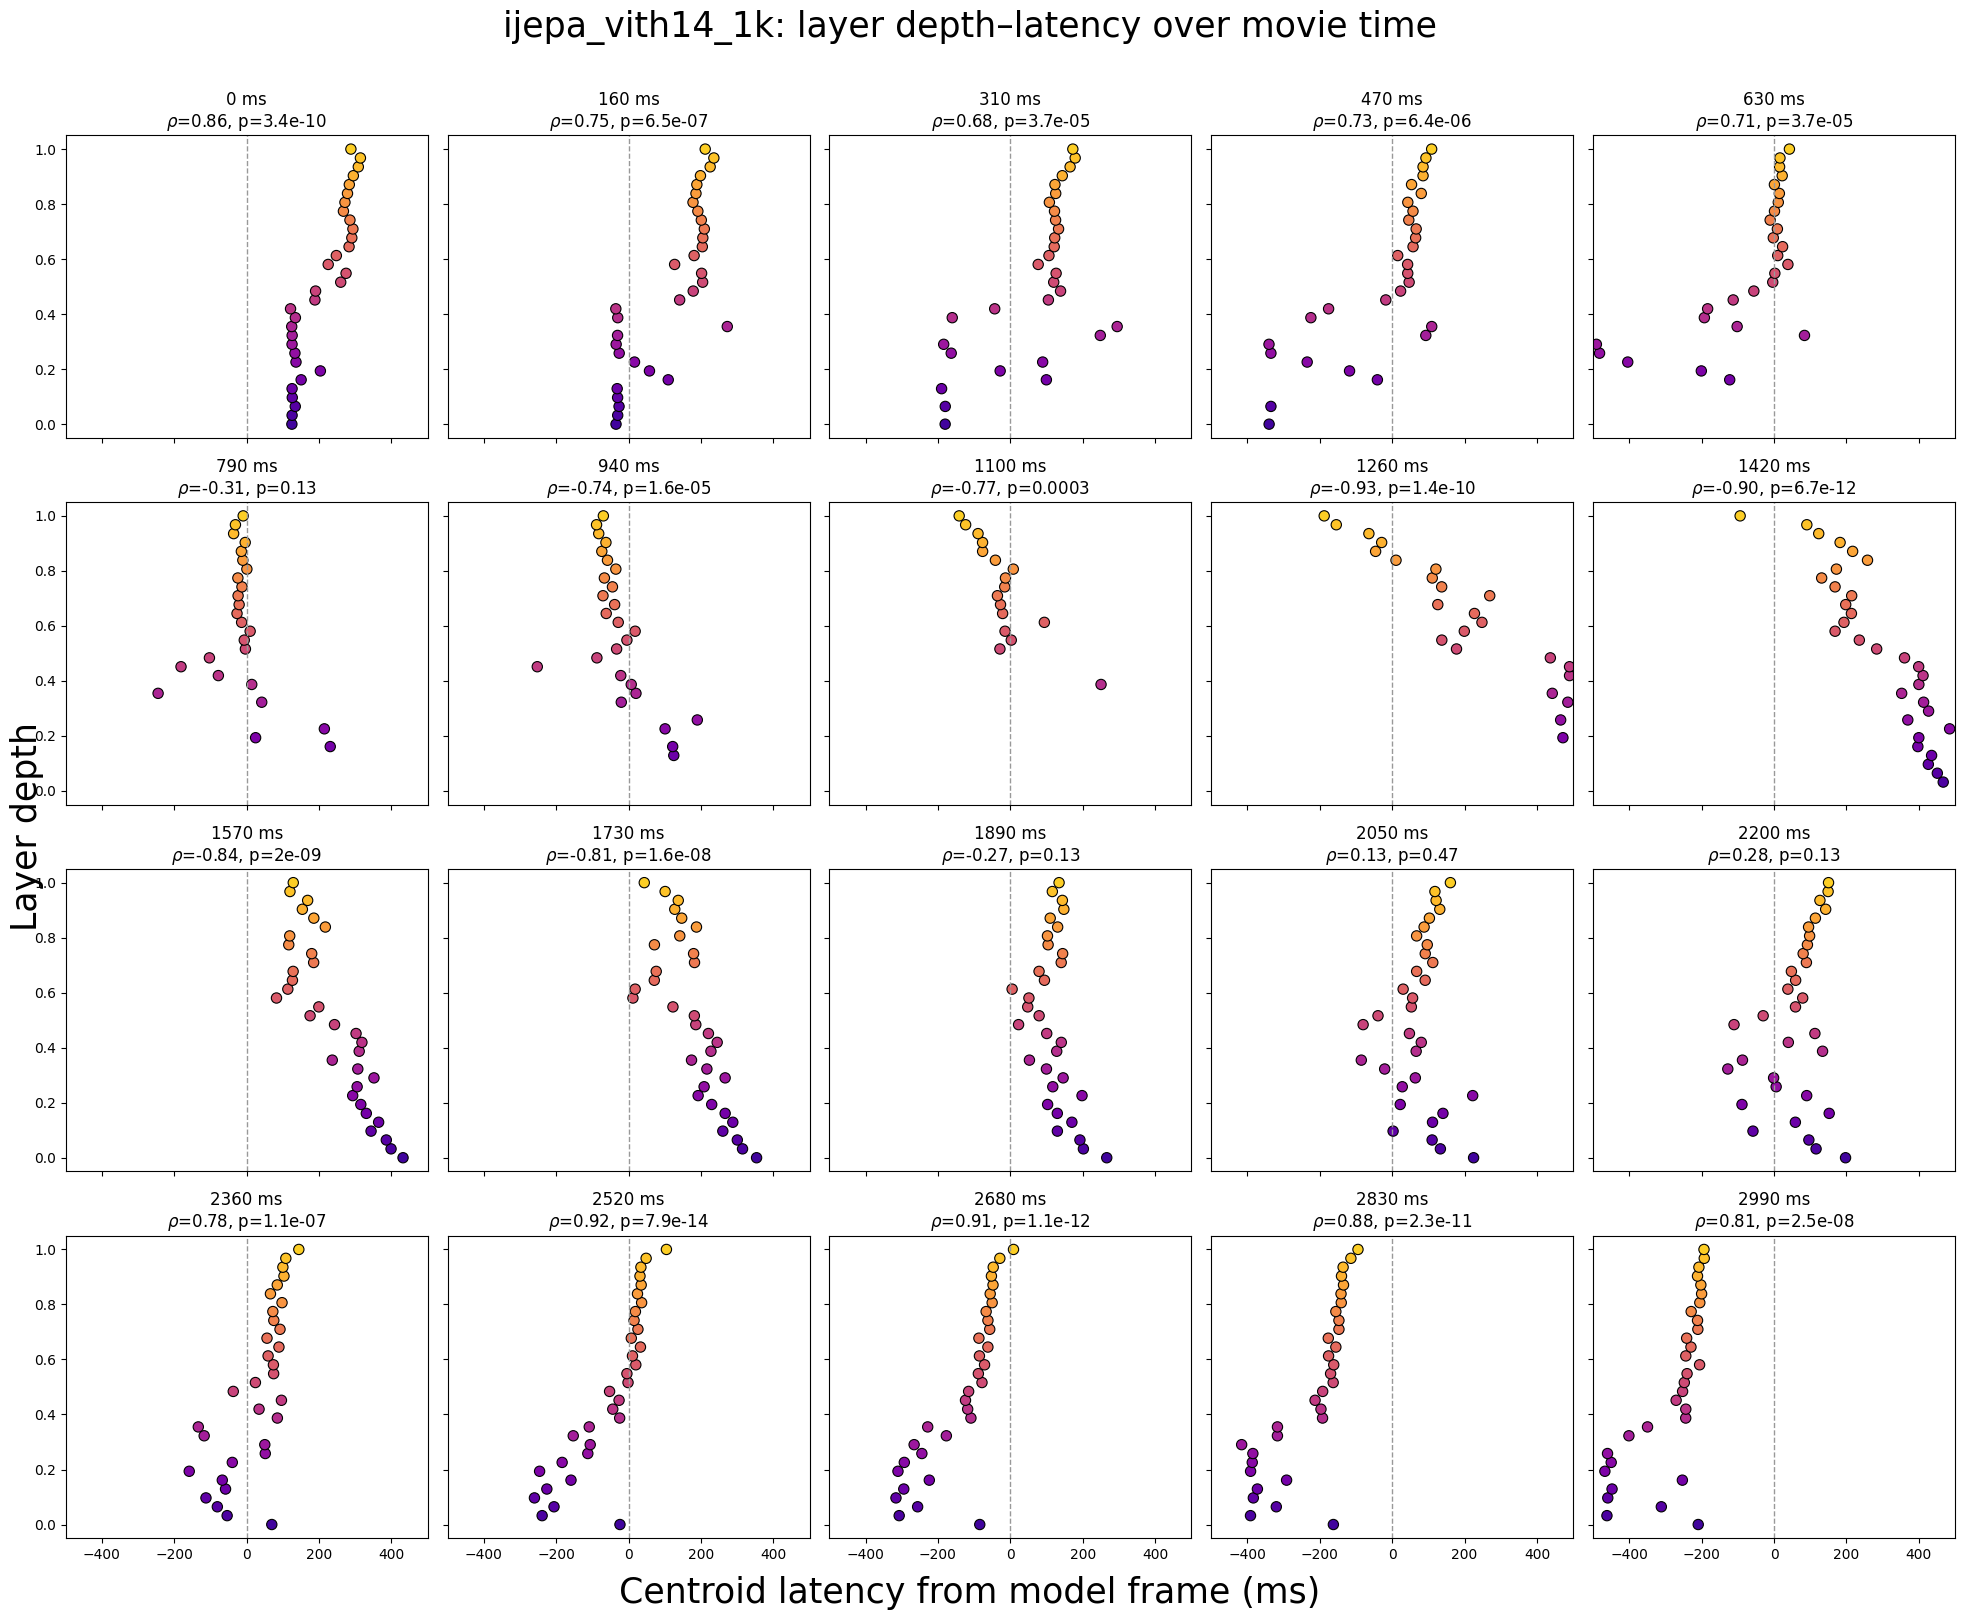

Loaded 32 saved layers; selected model frames: [0, 160, 310, 470, 630, 790, 940, 1100, 1260, 1420, 1570, 1730, 1890, 2050, 2200, 2360, 2520, 2680, 2830, 2990] ms


In [ ]:
if saved_model_time_ms.size < cfg.frame_latency_n_scatterplots:
    raise ValueError(
        'There are fewer saved model frames than requested scatterplots.'
    )
# end if there are too few model frames

# Round an evenly spaced grid to actual saved model-frame indices.
selected_frame_indices = np.rint(np.linspace(
    0, saved_model_time_ms.size - 1, cfg.frame_latency_n_scatterplots,
)).astype(int)
if np.unique(selected_frame_indices).size != cfg.frame_latency_n_scatterplots:
    raise ValueError('Even frame sampling produced duplicate frame indices.')
# end if selected frame indices are not unique

saved_layer_depths = np.linspace(0, 1, len(saved_layer_results))
saved_layer_cmap = truncate_colormap(
    plt.get_cmap(cfg.latency_scatter_cmap),
    cfg.latency_scatter_cmap_min, cfg.latency_scatter_cmap_max,
)
saved_layer_colors = saved_layer_cmap(saved_layer_depths)
frame_latency_values_ms = np.full(
    (cfg.frame_latency_n_scatterplots, len(saved_layer_results)), np.nan,
)
frame_latency_correlations = np.full(
    (cfg.frame_latency_n_scatterplots, 2), np.nan,
)

for plot_index, frame_index in enumerate(selected_frame_indices):
    frame_time_ms = saved_model_time_ms[frame_index]
    relative_neural_time_ms = saved_neural_time_ms - frame_time_ms
    latency_window = (
        (relative_neural_time_ms >= cfg.frame_latency_window_ms[0])
        & (relative_neural_time_ms < cfg.frame_latency_window_ms[1])
    )
    if not latency_window.any():
        raise ValueError(f'Frame {frame_time_ms:g} ms has an empty latency window.')
    # end if latency window is empty

    window_time_ms = relative_neural_time_ms[latency_window]
    for layer_index in range(len(saved_layer_results)):
        layer_similarity = saved_dynamic_rsa[
            layer_index, :, frame_index
        ].copy()
        if cfg.smoothing:
            layer_similarity = gaussian_filter1d(
                layer_similarity, sigma=cfg.smoothing,
            )
        # end if cfg.smoothing
        window_similarity = layer_similarity[latency_window]

        if cfg.frame_latency_measure == 'centroid':
            # Positive RSA above cutoff supplies the centroid weights.
            latency_weights = np.where(
                np.isfinite(window_similarity)
                & (window_similarity > cfg.centroid_similarity_cutoff),
                window_similarity, 0,
            )
            if latency_weights.sum() > 0:
                frame_latency_values_ms[plot_index, layer_index] = (
                    np.average(window_time_ms, weights=latency_weights)
                )
            # end if the layer has positive centroid weight
        else:
            # Peak latency uses the strongest finite RSA above its cutoff.
            peak_similarity = np.where(
                np.isfinite(window_similarity)
                & (window_similarity > cfg.peak_similarity_cutoff),
                window_similarity, 0,
            )
            if peak_similarity.max(initial=0) > 0:
                frame_latency_values_ms[plot_index, layer_index] = (
                    window_time_ms[np.argmax(peak_similarity)]
                )
            # end if the layer has a valid peak
        # end if cfg.frame_latency_measure == 'centroid'
    # end for layer_index

    valid_layers = np.isfinite(frame_latency_values_ms[plot_index])
    if valid_layers.sum() >= 2:
        correlation_result = spearmanr(
            frame_latency_values_ms[plot_index, valid_layers],
            saved_layer_depths[valid_layers],
        )
        frame_latency_correlations[plot_index] = (
            correlation_result.statistic, correlation_result.pvalue,
        )
    # end if at least two layer latencies are valid
# end for plot_index, frame_index

# Use shared axes so changes across movie time can be compared directly.
n_rows, n_columns = cfg.frame_latency_grid_shape
figure, axes = plt.subplots(
    n_rows, n_columns, figsize=cfg.frame_latency_grid_figsize,
    sharex=True, sharey=True,
)
for plot_index, (axis, frame_index) in enumerate(
        zip(axes.flat, selected_frame_indices),
        ):
    valid_layers = np.isfinite(frame_latency_values_ms[plot_index])
    axis.scatter(
        frame_latency_values_ms[plot_index, valid_layers],
        saved_layer_depths[valid_layers],
        c=saved_layer_colors[valid_layers],
        s=cfg.frame_latency_scatter_size,
        edgecolors=cfg.latency_scatter_edge_color,
        linewidths=cfg.latency_scatter_edge_width,
    )
    rho_value, p_value = frame_latency_correlations[plot_index]
    axis.set_title(
        f'{saved_model_time_ms[frame_index]:.0f} ms\n'
        fr'$\rho$={rho_value:.2f}, p={p_value:.2g}',
        fontsize=12,
    )
    axis.axvline(0, color='0.6', linewidth=1, linestyle='--')
    axis.set(
        xlim=cfg.frame_latency_window_ms, ylim=(-0.05, 1.05),
        yticks=cfg.latency_scatter_y_ticks,
    )
    axis.tick_params(axis='both', labelsize=10)
# end for plot_index, axis, frame_index

figure.supxlabel(
    f'{cfg.frame_latency_measure.capitalize()} latency from model frame (ms)',
    fontsize=cfg.label_size,
)
figure.supylabel('Layer depth', fontsize=cfg.label_size)
figure.suptitle(
    f'{cfg.model_name}: layer depth–latency over movie time',
    fontsize=cfg.label_size, y=1.01,
)
figure.tight_layout()

if cfg.fig_save:
    figure.savefig(
        f'{cfg.figs_dir}/{cfg.monkey_name}_{cfg.vid_exp_name}_'
        f'{cfg.model_name}_20_frame_'
        f'{cfg.frame_latency_measure}_latency_by_layer.pdf',
        bbox_inches='tight',
    )
# end if cfg.fig_save

plt.show()
print(
    f'Loaded {len(saved_layer_results)} saved layers; selected model frames: '
    f'{saved_model_time_ms[selected_frame_indices].astype(int).tolist()} ms'
)
# EOF
